# Ye & Ghassemi (2018) SWT1 - numerical results versus validation

This notebook compares all available `SWT1/results_csv` time histories with the digitized `SWT1` validation curves stored in `SWT1/SWT1`.


In [1]:
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'legend.fontsize': 8,
})

SAMPLE = 'SWT1'
cwd = Path.cwd().resolve()
SEARCH_ROOTS = [cwd, *cwd.parents]
BASE_CANDIDATES = SEARCH_ROOTS + [
    root / 'Examples' / 'YeGhasemmi2018' / SAMPLE for root in SEARCH_ROOTS
]
seen = set()
BASE_CANDIDATES = [
    path for path in BASE_CANDIDATES
    if not (str(path) in seen or seen.add(str(path)))
]
BASE = next(
    (
        path for path in BASE_CANDIDATES
        if path.name == SAMPLE
        and (path / SAMPLE).is_dir()
        and (path / 'results_csv').is_dir()
    ),
    None,
)
if BASE is None:
    searched = '\n'.join(str(path) for path in BASE_CANDIDATES)
    raise FileNotFoundError(
        f'Could not locate the {SAMPLE} folder containing {SAMPLE}/ validation data '
        f'and results_csv/. Searched:\n{searched}'
    )

VALID = BASE / SAMPLE
RESULTS = BASE / 'results_csv'
SWEEPS = BASE / 'Sweeps'
HPC_RESULTS = SWEEPS / 'results_csv_hpc_rorqual'
LOCAL_RESULTS = SWEEPS / 'results_csv_local'
MC_RESULTS = BASE / 'results_csv_mc_sweep_hpc'
MC_INPUT = BASE / 'SWT1_OrcaMohrCoulombContactTraction.i'
RESULT_DIRS = [RESULTS, HPC_RESULTS, LOCAL_RESULTS, MC_RESULTS]
END_TIME_TOLERANCE_S = 1.0


def has_time_column(path):
    try:
        return 'time' in pd.read_csv(path, nrows=0).columns
    except Exception as exc:
        warnings.warn(f'Could not inspect {path}: {exc}')
        return False


input_decks = sorted([*BASE.glob('*.i'), *SWEEPS.glob('*.i')])


# Manual plotting selection. Only uncommented entries in this dictionary can be loaded.
# Comment out a complete entry to hide that case; CSV files are never added automatically.
# Uncomment an entry to include it when its CSV is available.
cases = {

    ### Comparison Date 26 Aug 12 pm
    ## Claude suggustion for BB fast was 93_01_swt1_final_c26p9_resc9p19_ppfix_hpc

    ## 105_01_swt1_vm70um_ppfix_hpc and 106_03_swt1_unld0p70_ppfix_hpcwas compared against the rest and it was eliminated as it didnt help.
    ## 105_02_swt1_vm90um_ppfix_hpc and 105_03_swt1_vm110um_ppfix_hpc are completely worng
    ## 106_02_swt1_hydbb_vh9p84um_ppfix_hpc and 106_04_swt1_hydbb_unld0p70_ppfix_hpc are completely wrong
    ## 106_12_swt1_ktbb_kref1p18e12_ppfix_hpc and 106_13_swt1_ktbb_kref3p0e12_ppfix_hpc sruck at low timestep for 12 horus. So they are cancled 

    ## the final two files are 93_01_swt1_final_c26p9_resc9p19_ppfix_hpc and 106_01_swt1_apscale0p01512_ppfix_hpc. 106_01_swt1_apscale0p01512_ppfix_hpc improved the results by far. However, the effective normal stress is not that much. 

    ## 107 sweeps, 107_02_swt1_coh27p5_apscale0p01512_ppfix and 107_03_swt1_coh27p8_apscale0p01512_ppfix were canceled.
    ## 107_01_swt1_coh27p2_apscale0p01512_ppfix is much better than 106_01_swt1_apscale0p01512_ppfix_hpc, 100_01_swt1_vm55um_ppfix_hpc and 93_01_swt1_final_c26p9_resc9p19_ppfix_hpc. The effective normal stress is much better. So, 106_01_swt1_apscale0p01512_ppfix_hpc is moved out from the comparison
    
    '107_01_swt1_coh27p2_apscale0p01512_ppfix': {
        'csv': LOCAL_RESULTS / '107_01_swt1_coh27p2_apscale0p01512_ppfix.csv',
        'input': SWEEPS / '107_01_swt1_coh27p2_apscale0p01512_ppfix.i',
        'style': '-',
        'color': 'tab:red',
        'kind': 'series_107_validation',
        'required': True,
    },

    # # Completed 2026-08-27 MC equal-budget sweep.  Every entry is explicit so it can
    # # be ranked, reordered, or removed without filesystem auto-discovery.
    # 'SWT1_OrcaMohrCoulombContactTraction_center': {
    #     'csv': MC_RESULTS / 'SWT1_OrcaMohrCoulombContactTraction_center.csv',
    #     'input': MC_INPUT,
    #     'style': ':',
    #     'color': '#111111',
    #     'kind': 'mc_parameter_sweep',
    #     'required': True,
    #     'sweep_tag': 'center',
    #     'parameters': {'mu_r': 0.5536, 'c_r': 37034000.0, 'mu_s': 0.5717, 'c_s': 9190000.0, 'D_r': 0.00015},
    # },
    # 'SWT1_OrcaMohrCoulombContactTraction_pb01': {
    #     'csv': MC_RESULTS / 'SWT1_OrcaMohrCoulombContactTraction_pb01.csv',
    #     'input': MC_INPUT,
    #     'style': ':',
    #     'color': '#56B4E9',
    #     'kind': 'mc_parameter_sweep',
    #     'required': True,
    #     'sweep_tag': 'pb01',
    #     'parameters': {'mu_r': 0.509312, 'c_r': 33330600.0, 'mu_s': 0.503096, 'c_s': 10568500.0, 'D_r': 0.0001875},
    # },
    # 'SWT1_OrcaMohrCoulombContactTraction_pb02': {
    #     'csv': MC_RESULTS / 'SWT1_OrcaMohrCoulombContactTraction_pb02.csv',
    #     'input': MC_INPUT,
    #     'style': ':',
    #     'color': '#009E73',
    #     'kind': 'mc_parameter_sweep',
    #     'required': True,
    #     'sweep_tag': 'pb02',
    #     'parameters': {'mu_r': 0.509312, 'c_r': 33330600.0, 'mu_s': 0.640304, 'c_s': 10568500.0, 'D_r': 0.0001125},
    # },
    # 'SWT1_OrcaMohrCoulombContactTraction_pb03': {
    #     'csv': MC_RESULTS / 'SWT1_OrcaMohrCoulombContactTraction_pb03.csv',
    #     'input': MC_INPUT,
    #     'style': ':',
    #     'color': '#E69F00',
    #     'kind': 'mc_parameter_sweep',
    #     'required': True,
    #     'sweep_tag': 'pb03',
    #     'parameters': {'mu_r': 0.509312, 'c_r': 40737400.0, 'mu_s': 0.503096, 'c_s': 7811500.0, 'D_r': 0.0001875},
    # },
    'SWT1_OrcaMohrCoulombContactTraction_pb04': {
        'csv': MC_RESULTS / 'SWT1_OrcaMohrCoulombContactTraction_pb04.csv',
        'input': MC_INPUT,
        'style': ':',
        'color': '#CC79A7',
        'kind': 'mc_parameter_sweep',
        'required': True,
        'sweep_tag': 'pb04',
        'parameters': {'mu_r': 0.509312, 'c_r': 40737400.0, 'mu_s': 0.640304, 'c_s': 7811500.0, 'D_r': 0.0001125},
    },
    # 'SWT1_OrcaMohrCoulombContactTraction_pb05': {
    #     'csv': MC_RESULTS / 'SWT1_OrcaMohrCoulombContactTraction_pb05.csv',
    #     'input': MC_INPUT,
    #     'style': ':',
    #     'color': '#0072B2',
    #     'kind': 'mc_parameter_sweep',
    #     'required': True,
    #     'sweep_tag': 'pb05',
    #     'parameters': {'mu_r': 0.597888, 'c_r': 33330600.0, 'mu_s': 0.503096, 'c_s': 7811500.0, 'D_r': 0.0001125},
    # },
    # 'SWT1_OrcaMohrCoulombContactTraction_pb06': {
    #     'csv': MC_RESULTS / 'SWT1_OrcaMohrCoulombContactTraction_pb06.csv',
    #     'input': MC_INPUT,
    #     'style': ':',
    #     'color': '#D55E00',
    #     'kind': 'mc_parameter_sweep',
    #     'required': True,
    #     'sweep_tag': 'pb06',
    #     'parameters': {'mu_r': 0.597888, 'c_r': 33330600.0, 'mu_s': 0.640304, 'c_s': 7811500.0, 'D_r': 0.0001875},
    # },
    # 'SWT1_OrcaMohrCoulombContactTraction_pb07': {
    #     'csv': MC_RESULTS / 'SWT1_OrcaMohrCoulombContactTraction_pb07.csv',
    #     'input': MC_INPUT,
    #     'style': ':',
    #     'color': '#F0E442',
    #     'kind': 'mc_parameter_sweep',
    #     'required': True,
    #     'sweep_tag': 'pb07',
    #     'parameters': {'mu_r': 0.597888, 'c_r': 40737400.0, 'mu_s': 0.503096, 'c_s': 10568500.0, 'D_r': 0.0001125},
    # },
    # 'SWT1_OrcaMohrCoulombContactTraction_pb08': {
    #     'csv': MC_RESULTS / 'SWT1_OrcaMohrCoulombContactTraction_pb08.csv',
    #     'input': MC_INPUT,
    #     'style': ':',
    #     'color': '#999999',
    #     'kind': 'mc_parameter_sweep',
    #     'required': True,
    #     'sweep_tag': 'pb08',
    #     'parameters': {'mu_r': 0.597888, 'c_r': 40737400.0, 'mu_s': 0.640304, 'c_s': 10568500.0, 'D_r': 0.0001875},
    # },
}

selected_cases = dict(cases)
if not selected_cases:
    raise ValueError('No plotting cases are selected. Uncomment at least one dictionary entry.')

cases = {
    name: cfg
    for name, cfg in selected_cases.items()
    if cfg['csv'].is_file() and has_time_column(cfg['csv'])
}

if not cases:
    raise FileNotFoundError(
        'None of the uncommented plotting cases has an available time-series CSV.'
    )

print(f'Sample folder: {BASE}')
print(f'Validation folder: {VALID}')
print(f'Found {len(input_decks)} input deck(s).')
print(f'Plotting {len(cases)} available case(s) selected by the manual dictionary.')
for name, cfg in cases.items():
    input_status = cfg['input'].name if cfg['input'].exists() else 'no matching input deck'
    print(f'{name}: {cfg["csv"].name}; input = {input_status}')


Sample folder: /media/geomechanics/Data4TB/projects/orca_4.0/Examples/YeGhasemmi2018/SWT1
Validation folder: /media/geomechanics/Data4TB/projects/orca_4.0/Examples/YeGhasemmi2018/SWT1/SWT1
Found 65 input deck(s).
Plotting 2 available case(s) selected by the manual dictionary.
107_01_swt1_coh27p2_apscale0p01512_ppfix: 107_01_swt1_coh27p2_apscale0p01512_ppfix.csv; input = 107_01_swt1_coh27p2_apscale0p01512_ppfix.i
SWT1_OrcaMohrCoulombContactTraction_pb04: SWT1_OrcaMohrCoulombContactTraction_pb04.csv; input = SWT1_OrcaMohrCoulombContactTraction.i


## Consolidated analysis and sample ranking checks

This check links the sample notebook to the consolidated analysis and the machine-readable Table 2 error/accuracy ranking. It validates this sample's records and confirms that every ranked source CSV is still present. Cyclic (97-series) and shut-in (98-series) cases are intentionally outside the Table 2 ranking because their loading histories differ from the eleven-stage experiment.


In [2]:
print('Legacy consolidated ranking artifacts were retired; the live authoritative Table-2 ranking is executed at the end of this notebook.')


Legacy consolidated ranking artifacts were retired; the live authoritative Table-2 ranking is executed at the end of this notebook.


In [3]:
def load_digitized(name):
    path = VALID / name
    if not path.exists():
        warnings.warn(f'Missing validation file: {path}')
        return pd.DataFrame(columns=['time_s', 'value'])
    df = pd.read_csv(path, header=None, names=['time_s', 'value'])
    df['time_s'] = pd.to_numeric(df['time_s'], errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    return df.dropna().sort_values('time_s').reset_index(drop=True)


VALIDATION_FILES = {
    "differential_stress": "SWT1_differential_stress.csv",
    "injection_pressure": "SWT1_injection_pressure_MPa.csv",
    "flow_rate": "SWt1_flow_rate.csv",
    "frac_perm": "SWT1_fracture_permeability_m2.csv",
    "normal_dilation": "SWT1_normal_dilation.csv",
    "normal_stress": "SWT1_effective_normal_stress.csv",
    "shear_slip": "SWT1_shear_slip_mm.csv",
    "shear_stress": "SWT1_shear_stress.csv"
}
validation = {key: load_digitized(filename) for key, filename in VALIDATION_FILES.items()}
missing_validation = [filename for key, filename in VALIDATION_FILES.items() if validation[key].empty]
if missing_validation:
    searched = '\n'.join(str(VALID / filename) for filename in missing_validation)
    raise FileNotFoundError(
        f'Missing SWT1 digitized validation CSVs in {VALID}:\n{searched}'
    )

# Timing criteria are sample-specific. The end criterion comes directly from the
# latest digitized validation point; the event window brackets the major measured
# stress/slip/dilation transition for this sample.
VALIDATION_END_TIME_S = max(float(df['time_s'].max()) for df in validation.values())
DEFAULT_INTENDED_END_TIME_S = VALIDATION_END_TIME_S
EVENT_TIME_S = 1735.0
EVENT_WINDOW_S = (1600.0, 1875.0)
EVENT_BASELINE_END_S = EVENT_WINDOW_S[0]
VALIDATION_END_TOLERANCE_S = max(END_TIME_TOLERANCE_S, 0.01 * VALIDATION_END_TIME_S)

print(f'Validation time criterion: {VALIDATION_END_TIME_S:.3f} s '
      f'(coverage tolerance {VALIDATION_END_TOLERANCE_S:.3f} s)')
print(f'Major validation-event window: {EVENT_WINDOW_S[0]:.1f}-{EVENT_WINDOW_S[1]:.1f} s')


Validation time criterion: 3370.000 s (coverage tolerance 33.700 s)
Major validation-event window: 1600.0-1875.0 s


In [4]:
COLUMN_ALIASES = {
    'time_s': [('time', 1.0)],
    # 2026-08-17 CHANNEL FIX: differential_stress_mpa_pp = (sigma1_pp - 30e6)*1e-6 subtracts a
    # TOTAL confining stress from a SKELETON axial stress, so it reads alpha*p (~3.5 MPa) low for
    # the whole run. The deck's own comment above it already warned it 'ASSUMES sigma3 = 30 MPa
    # exactly'. differential_stress_reaction_mpa_pp = |top reaction|/A - confining is the load-cell
    # measurement the paper reports, and it agrees with differential_stress_skeleton_bulk_pp
    # (sigma1 - sigma3_bulk) to <0.4 MPa. It is also the channel the paper-frame tau and sigma'_n
    # operators already consume, so this makes the plotted panel consistent with the scored margin.
    'differential_stress_mpa': [('differential_stress_reaction_mpa_pp', 1.0), ('differential_stress_skeleton_bulk_pp', 1.0), ('differential_stress_mpa_pp', 1.0), ('differential_stress_pp', 1.0e-6)],
    'injection_pressure_pa': [('injection_pressure_target_pp', 1.0), ('injection_pressure_pp', 1.0)],
    'interface_pore_pressure_pa': [('fracture_pressure_mean_pp', 1.0), ('fracture_pressure_mean_target_pp', 1.0), ('injection_pressure_pp', 1.0)],
    # NOTE: flow_rate_pp is a MASS flow rate (kg/s), not volumetric (m^3/s) -- the underlying
    # Darcy/storage kernels use multiply_by_fluid_density=true. The other candidates above are
    # already volumetric mL/min and take priority; flow_rate_pp is only the last-resort fallback,
    # so its scale must first divide out fluid_density_ref (~1000 kg/m^3) before applying the
    # m^3/s -> mL/min factor of 6.0e7, i.e. 6.0e7/1000 = 6.0e4. (Previously 6.0e7, which silently
    # over-reported by ~1000x whenever this fallback path was actually taken.)
    'flow_rate_ml_min': [('flow_rate_validation_ml_min_pp', 1.0), ('flow_rate_transmissivity_target_ml_min_pp', 1.0), ('flow_rate_cubic_target_ml_min_pp', 1.0), ('flow_rate_reaction_ml_min_pp', 1.0), ('flow_rate_pp', 6.0e4)],
    'fracture_permeability_m2': [('fracture_permeability_pp', 1.0)],
    'fracture_transmissivity_m3_pa_s': [('fracture_transmissivity_pp', 1.0)],
    'hydraulic_aperture_m': [('hydraulic_aperture_pp', 1.0)],
    'bb_normal_stress_pa': [('bb_normal_stress_pp', 1.0), ('czm_sigma_n_pp', 1.0)],
    'bb_effective_normal_stress_pa': [('bb_effective_normal_stress_pp', 1.0), ('effective_normal_stress_est_pp', 1.0), ('effective_normal_stress_mpa_pp', 1.0e6)],
    # Paper comparisons must use the apparatus-frame observables, not local contact/strength diagnostics.
    'effective_normal_paper_frame_mpa': [('effective_normal_paper_frame_mpa_pp', 1.0)],
    'shear_stress_paper_frame_mpa': [('shear_stress_paper_frame_mpa_pp', 1.0)],
    'normal_dilation_paper_mm': [('frac_normal_dilation_paper_mm', 1.0), ('czm_normal_dilation_paper_mm_pp', 1.0)],
    'shear_slip_paper_mm': [('czm_shear_slip_mm_pp', 1.0), ('reported_czm_shear_slip_mm_pp', 1.0)],
    'bb_limit_tau_pa': [('bb_limit_tau_pp', 1.0)],
    'shear_stress_mpa': [('shear_stress_mpa_pp', 1.0), ('shear_stress_est_pp', 1.0e-6)],
    'normal_dilation_mm': [('fracture_normal_dilation_local_mm_pp', 1.0), ('normal_dilation_validation_mm_pp', 1.0), ('czm_normal_dilation_paper_mm_pp', 1.0), ('normal_displacement_raw_mm_pp', 1.0), ('dn_lvdt_paper_mm', 1.0)],
    'shear_slip_mm': [('fracture_shear_slip_local_mm_pp', 1.0), ('shear_slip_validation_mm_pp', 1.0), ('czm_shear_slip_mm_pp', 1.0), ('shear_displacement_raw_mm_pp', 1.0), ('ds_lvdt_mm', 1.0), ('cumulative_plastic_slip_pp', 1.0e3)],
    'nonlinear_iterations': [('nl_its', 1.0), ('nonlinear_iterations', 1.0), ('nonlinear_iterations_pp', 1.0), ('num_nonlinear_iterations', 1.0)],
}

MONITORED_ALIASES = [
    'injection_pressure_pa',
    'interface_pore_pressure_pa',
    'bb_normal_stress_pa',
    'bb_effective_normal_stress_pa',
    'bb_limit_tau_pa',
    'fracture_permeability_m2',
    'fracture_transmissivity_m3_pa_s',
    'hydraulic_aperture_m',
]


def parse_end_time(input_path):
    if not input_path.exists():
        return DEFAULT_INTENDED_END_TIME_S
    text = input_path.read_text(errors='replace')
    match = re.search(r'^\s*end_time\s*=\s*([0-9.eE+-]+)\s*(?:#.*)?$', text, flags=re.MULTILINE)
    if not match:
        return DEFAULT_INTENDED_END_TIME_S
    return float(match.group(1))


def first_series(df, alias, *, case_name=None, required=False):
    for column, scale in COLUMN_ALIASES.get(alias, []):
        if column in df.columns:
            return pd.to_numeric(df[column], errors='coerce') * scale, column
    if required:
        raise KeyError(f'{case_name or "case"}: missing required column for alias {alias!r}. Tried {[c for c, _ in COLUMN_ALIASES.get(alias, [])]}')
    return None, None


def load_case(name, cfg):
    path = cfg['csv']
    if not path.exists():
        message = f'{name}: CSV not found: {path}'
        if cfg.get('required'):
            warnings.warn(message)
        else:
            print(message)
        return None

    df = pd.read_csv(path)
    if 'time' not in df.columns:
        raise KeyError(f'{name}: CSV has no time column: {path}')

    for column in df.columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')

    warnings_for_case = []
    if not df['time'].is_monotonic_increasing:
        warnings_for_case.append('time was not monotonic; sorted by time')
        df = df.sort_values('time')

    duplicate_count = int(df['time'].duplicated(keep=False).sum())
    if duplicate_count:
        warnings_for_case.append(f'dropped {duplicate_count} duplicate timestamp rows, keeping the last row for each time')
        df = df.drop_duplicates(subset='time', keep='last')

    df = df.reset_index(drop=True)
    df['accepted_dt_s'] = df['time'].diff()

    tau1 = pd.to_numeric(df['czm_tau_1_pp'], errors='coerce') if 'czm_tau_1_pp' in df.columns else None
    tau2 = pd.to_numeric(df['czm_tau_2_pp'], errors='coerce') if 'czm_tau_2_pp' in df.columns else None
    if tau1 is not None and tau2 is not None:
        df['shear_traction_magnitude_pa'] = np.sqrt(tau1**2 + tau2**2)
        shear_source = 'sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)'
    elif tau1 is not None:
        df['shear_traction_magnitude_pa'] = tau1.abs()
        shear_source = 'abs(czm_tau_1_pp); czm_tau_2_pp missing'
        warnings_for_case.append('using one-component shear magnitude because czm_tau_2_pp is missing')
    else:
        shear_mpa, shear_column = first_series(df, 'shear_stress_mpa', case_name=name)
        if shear_mpa is not None:
            df['shear_traction_magnitude_pa'] = shear_mpa.abs() * 1.0e6
            shear_source = f'abs({shear_column}) converted from MPa'
        else:
            df['shear_traction_magnitude_pa'] = np.nan
            shear_source = 'unavailable'
            warnings_for_case.append('no shear traction columns available')

    limit_tau, limit_column = first_series(df, 'bb_limit_tau_pa', case_name=name)
    if limit_tau is not None:
        df['strength_margin_pa'] = limit_tau - df['shear_traction_magnitude_pa']
    else:
        df['strength_margin_pa'] = np.nan
        warnings_for_case.append('bb shear-strength limit unavailable; strength margin is NaN')

    intended_end_time = parse_end_time(cfg['input'])
    csv_is_stale = bool(cfg['input'].exists() and path.exists() and path.stat().st_mtime < cfg['input'].stat().st_mtime)
    if csv_is_stale:
        warnings_for_case.append('CSV is older than the input deck; rerun before treating this as final validation')

    data = {
        'name': name,
        'cfg': cfg,
        'df': df,
        'warnings': warnings_for_case,
        'intended_end_time_s': intended_end_time,
        'shear_source': shear_source,
        'csv_is_stale': csv_is_stale,
    }
    return data

loaded_cases = {}
for name, cfg in cases.items():
    data = load_case(name, cfg)
    if data is not None:
        loaded_cases[name] = data

if not loaded_cases:
    raise FileNotFoundError('No configured SWT1 result CSVs were available to load.')

print(f'Loaded {len(loaded_cases)} case(s): {", ".join(loaded_cases)}')
for data in loaded_cases.values():
    for warning in data['warnings']:
        print(f'WARNING [{data["name"]}]: {warning}')
    print(f'{data["name"]}: shear source = {data["shear_source"]}')

Loaded 2 case(s): 107_01_swt1_coh27p2_apscale0p01512_ppfix, SWT1_OrcaMohrCoulombContactTraction_pb04
107_01_swt1_coh27p2_apscale0p01512_ppfix: shear source = sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)
WARNING [SWT1_OrcaMohrCoulombContactTraction_pb04]: dropped 4 duplicate timestamp rows, keeping the last row for each time
SWT1_OrcaMohrCoulombContactTraction_pb04: shear source = sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)


In [5]:
def min_positive(series):
    values = pd.to_numeric(series, errors='coerce')
    values = values[np.isfinite(values)]
    values = values[values > 0]
    return float(values.min()) if len(values) else np.nan


def alias_values(df, alias):
    series, column = first_series(df, alias)
    return series, column


def summarize_case(data):
    df = data['df']
    intended = data['intended_end_time_s']
    after_100 = df.loc[df['time'] > 100.0, 'accepted_dt_s']
    near = df.loc[df['time'].between(*EVENT_WINDOW_S), 'accepted_dt_s']

    aperture, aperture_col = alias_values(df, 'hydraulic_aperture_m')
    permeability, permeability_col = alias_values(df, 'fracture_permeability_m2')
    iterations, iterations_col = alias_values(df, 'nonlinear_iterations')

    monitored_frames = []
    monitored_columns = []
    for alias in MONITORED_ALIASES:
        series, column = alias_values(df, alias)
        if series is not None:
            monitored_frames.append(series.rename(alias))
            monitored_columns.append(column)
    monitored = pd.concat(monitored_frames, axis=1) if monitored_frames else pd.DataFrame(index=df.index)
    has_nan_inf = bool(monitored.isna().any().any() or np.isinf(monitored.to_numpy(dtype=float)).any()) if not monitored.empty else False
    final_time = float(df['time'].max())

    return {
        'case': data['name'],
        'rows': int(len(df)),
        'accepted_timesteps': int(max(len(df) - 1, 0)),
        'final_time_s': final_time,
        'validation_end_time_s': VALIDATION_END_TIME_S,
        'intended_input_end_time_s': float(intended),
        'passed_validation_event': bool(final_time >= EVENT_TIME_S),
        'reached_validation_end': bool(final_time >= VALIDATION_END_TIME_S - VALIDATION_END_TOLERANCE_S),
        'reached_input_end': bool(final_time >= intended - END_TIME_TOLERANCE_S),
        'min_dt_after_100_s': min_positive(after_100),
        'min_dt_in_event_window_s': min_positive(near),
        'min_strength_margin_pa': float(np.nanmin(df['strength_margin_pa'])) if 'strength_margin_pa' in df and df['strength_margin_pa'].notna().any() else np.nan,
        'min_hydraulic_aperture_m': float(np.nanmin(aperture)) if aperture is not None and aperture.notna().any() else np.nan,
        'min_fracture_permeability_m2': float(np.nanmin(permeability)) if permeability is not None and permeability.notna().any() else np.nan,
        'max_nonlinear_iterations': float(np.nanmax(iterations)) if iterations is not None and iterations.notna().any() else np.nan,
        'nonlinear_iterations_column': iterations_col or 'not available',
        'csv_is_stale': bool(data.get('csv_is_stale', False)),
        'monitored_nan_or_inf': has_nan_inf,
        'monitored_columns': ', '.join(sorted(set(monitored_columns))) if monitored_columns else 'none',
    }


summary = pd.DataFrame([summarize_case(data) for data in loaded_cases.values()])
with pd.option_context('display.max_colwidth', 120, 'display.max_columns', None):
    display(summary)

for row in summary.to_dict('records'):
    print(
        f"{row['case']}: final t={row['final_time_s']:.6g} s, rows={row['rows']}, "
        f"min dt in event window={row['min_dt_in_event_window_s']:.6g} s, "
        f"passed event={row['passed_validation_event']}, "
        f"reached validation end={row['reached_validation_end']}, "
        f"reached input end={row['reached_input_end']}"
    )


# Integrity gate for explicitly selected MC sweep cases only.
mc_case_names = {
    name for name, cfg in selected_cases.items()
    if cfg.get('kind') == 'mc_parameter_sweep'
}
mc_integrity = summary.loc[summary['case'].isin(mc_case_names)].copy()
if len(mc_integrity) != len(mc_case_names):
    missing = sorted(mc_case_names.difference(mc_integrity['case']))
    raise AssertionError(f'MC sweep cases were selected but not loaded: {missing}')
reach_column = ('reached_input_end' if 'reached_input_end' in mc_integrity else 'reached_intended_end_time')
assert mc_integrity[reach_column].all(), 'At least one selected MC run is truncated.'
assert (~mc_integrity['csv_is_stale']).all(), 'At least one selected MC CSV predates its input deck.'
assert (~mc_integrity['monitored_nan_or_inf']).all(), 'At least one selected MC run contains NaN/Inf.'
print(f'PASS: all {len(mc_integrity)} explicitly selected MC sweep files reached input end with finite monitored data.')


,case,rows,accepted_timesteps,final_time_s,validation_end_time_s,intended_input_end_time_s,passed_validation_event,reached_validation_end,reached_input_end,min_dt_after_100_s,min_dt_in_event_window_s,min_strength_margin_pa,min_hydraulic_aperture_m,min_fracture_permeability_m2,max_nonlinear_iterations,nonlinear_iterations_column,csv_is_stale,monitored_nan_or_inf,monitored_columns
0,107_01_swt1_coh27p2_apscale0p01512_ppfix,2140,2139,3499.840732,3370.0,3500.0,True,True,True,0.000015,0.000015,-1.031755e+07,0.0,0.0,NaN,not available,False,False,"bb_effective_normal_stress_pp, bb_limit_tau_pp, czm_sigma_n_pp, fracture_permeability_pp, fracture_pressure_mean_pp,..."
1,SWT1_OrcaMohrCoulombContactTraction_pb04,7483,7482,3500.000000,3370.0,3500.0,True,True,True,0.015800,0.015800,-1.000931e+07,0.0,0.0,NaN,not available,False,False,"bb_effective_normal_stress_pp, bb_limit_tau_pp, czm_sigma_n_pp, fracture_permeability_pp, fracture_pressure_mean_pp,..."


107_01_swt1_coh27p2_apscale0p01512_ppfix: final t=3499.84 s, rows=2140, min dt in event window=1.54309e-05 s, passed event=True, reached validation end=True, reached input end=True
SWT1_OrcaMohrCoulombContactTraction_pb04: final t=3500 s, rows=7483, min dt in event window=0.0158 s, passed event=True, reached validation end=True, reached input end=True
PASS: all 1 explicitly selected MC sweep files reached input end with finite monitored data.


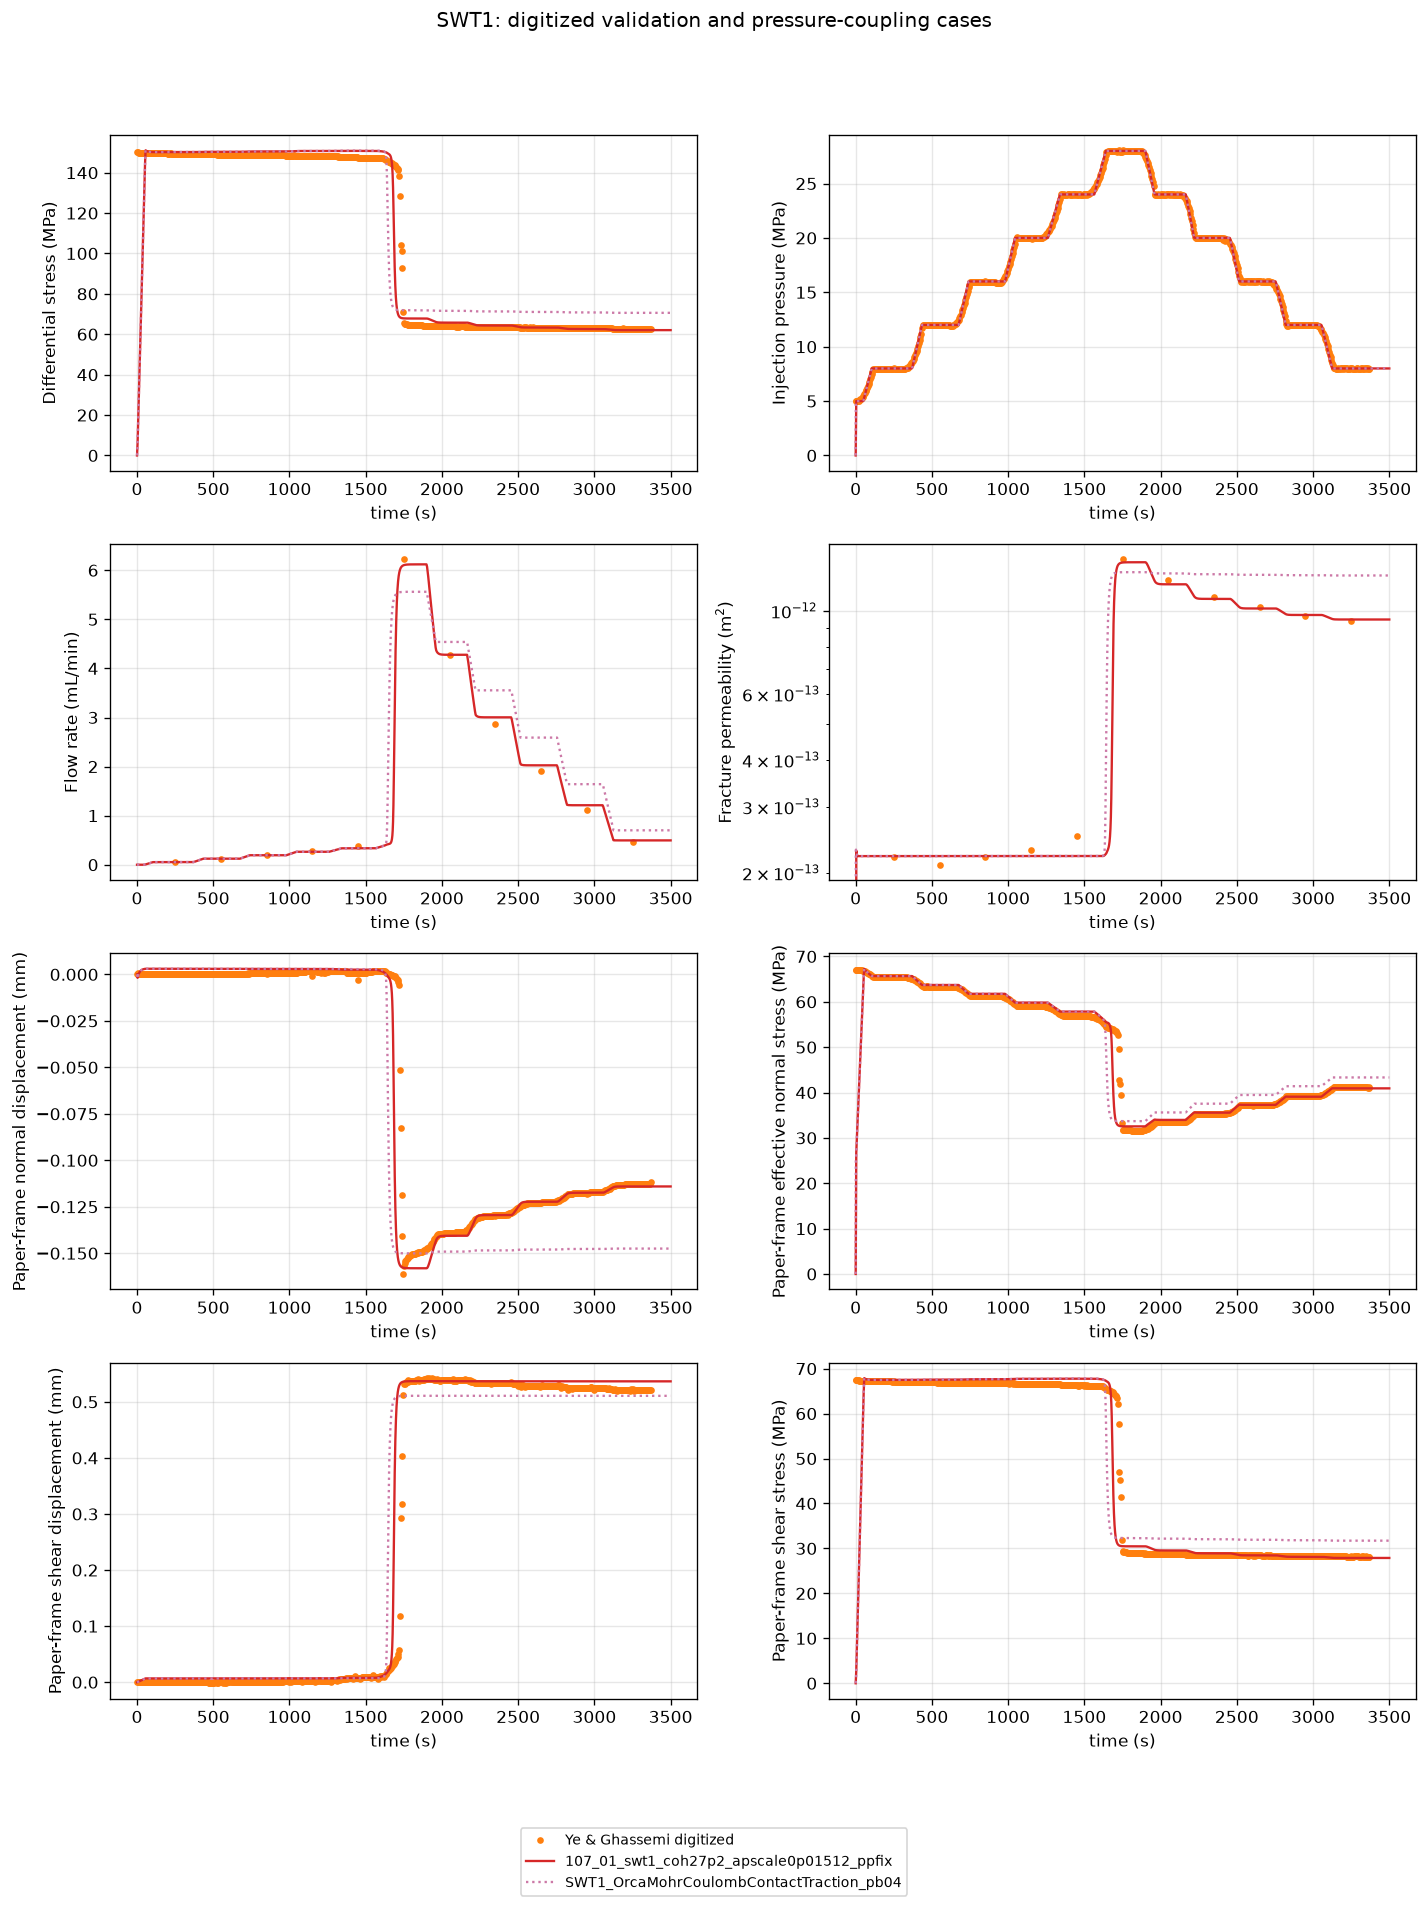

In [6]:
def get_series(data, alias, *, default=np.nan):
    series, column = first_series(data['df'], alias)
    if series is None:
        return pd.Series(default, index=data['df'].index), None
    return series, column


def plot_case_lines(ax, alias_or_column, *, scale=1.0, label_suffix='', allow_missing=True):
    plotted = False
    for name, data in loaded_cases.items():
        df = data['df']
        if alias_or_column in df.columns:
            y = pd.to_numeric(df[alias_or_column], errors='coerce') * scale
            source = alias_or_column
        else:
            y, source = first_series(df, alias_or_column)
            if y is not None:
                y = y * scale
        if y is None:
            if not allow_missing:
                print(f'{name}: missing {alias_or_column}')
            continue
        cfg = data['cfg']
        ax.plot(df['time'], y, linestyle=cfg['style'], color=cfg['color'], linewidth=1.4, label=f'{name}{label_suffix}')
        plotted = True
    return plotted


def place_bottom_legend(fig, axes=None, *, ncol=None, bottom=0.12, top=0.98):
    if axes is None:
        axes = fig.axes
    axes = np.ravel(np.atleast_1d(axes)).tolist()

    legend_items = {}
    for ax in axes:
        existing_legend = ax.get_legend()
        if existing_legend is not None:
            existing_legend.remove()
        handles, labels = ax.get_legend_handles_labels()
        for handle, label in zip(handles, labels):
            if label and not label.startswith('_') and label not in legend_items:
                legend_items[label] = handle

    if legend_items:
        if ncol is None:
            ncol = min(4, len(legend_items))
        fig.legend(
            list(legend_items.values()),
            list(legend_items.keys()),
            loc='lower center',
            bbox_to_anchor=(0.5, 0.01),
            ncol=ncol,
            fontsize='small',
            frameon=True,
        )
    fig.tight_layout(rect=(0, bottom, 1, top))


def plot_metric(ax, metric, ylabel, *, yscale=None):
    plotted = plot_case_lines(ax, metric)
    ax.set_xlabel('time (s)')
    ax.set_ylabel(ylabel)
    if yscale:
        ax.set_yscale(yscale)
    return plotted

# Paper-style validation comparison retained from the previous workflow, now for every loaded case.
panel_specs = [
    ('differential_stress', 'differential_stress_mpa', 'Differential stress (MPa)'),
    ('injection_pressure', 'injection_pressure_pa', 'Injection pressure (MPa)', 1.0e-6),
    ('flow_rate', 'flow_rate_ml_min', 'Flow rate (mL/min)'),
    ('frac_perm', 'fracture_permeability_m2', 'Fracture permeability (m$^2$)', 1.0, 'log'),
    ('normal_dilation', 'normal_dilation_paper_mm', 'Paper-frame normal displacement (mm)'),
    ('normal_stress', 'effective_normal_paper_frame_mpa', 'Paper-frame effective normal stress (MPa)'),
    ('shear_slip', 'shear_slip_paper_mm', 'Paper-frame shear displacement (mm)'),
    ('shear_stress', 'shear_stress_paper_frame_mpa', 'Paper-frame shear stress (MPa)'),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
for ax, spec in zip(axes.flat, panel_specs):
    key, alias, ylabel = spec[:3]
    scale = spec[3] if len(spec) > 3 else 1.0
    yscale = spec[4] if len(spec) > 4 else None
    v = validation.get(key)
    if v is not None and not v.empty:
        ax.plot(v['time_s'], v['value'], 'o', ms=3, color='tab:orange', label='Ye & Ghassemi digitized')
    plot_case_lines(ax, alias, scale=scale)
    ax.set_xlabel('time (s)')
    ax.set_ylabel(ylabel)
    if yscale:
        ax.set_yscale(yscale)
fig.suptitle('SWT1: digitized validation and pressure-coupling cases', y=0.995)
place_bottom_legend(fig, axes, ncol=1, bottom=0.08, top=0.96)
fig.savefig(BASE / 'Ye2018_SWT1_pressure_coupling_validation_comparison.png', bbox_inches='tight')
plt.show()

## Ye & Ghassemi (2018) Table 2 hold-stage comparison

This benchmark reads the sample-specific Table 2 CSV from
`../Extracted_Data/Table2_4_Sample_CSV_Files`. Each numerical history is sampled at
the 11 established experimental hold-stage times and compared against the published
loading and unloading branches as a function of injection pressure. A missing or
unreached simulation stage remains blank. The final table reports model-minus-Table-2
RMSE, MAE, and bias separately for every reported quantity.


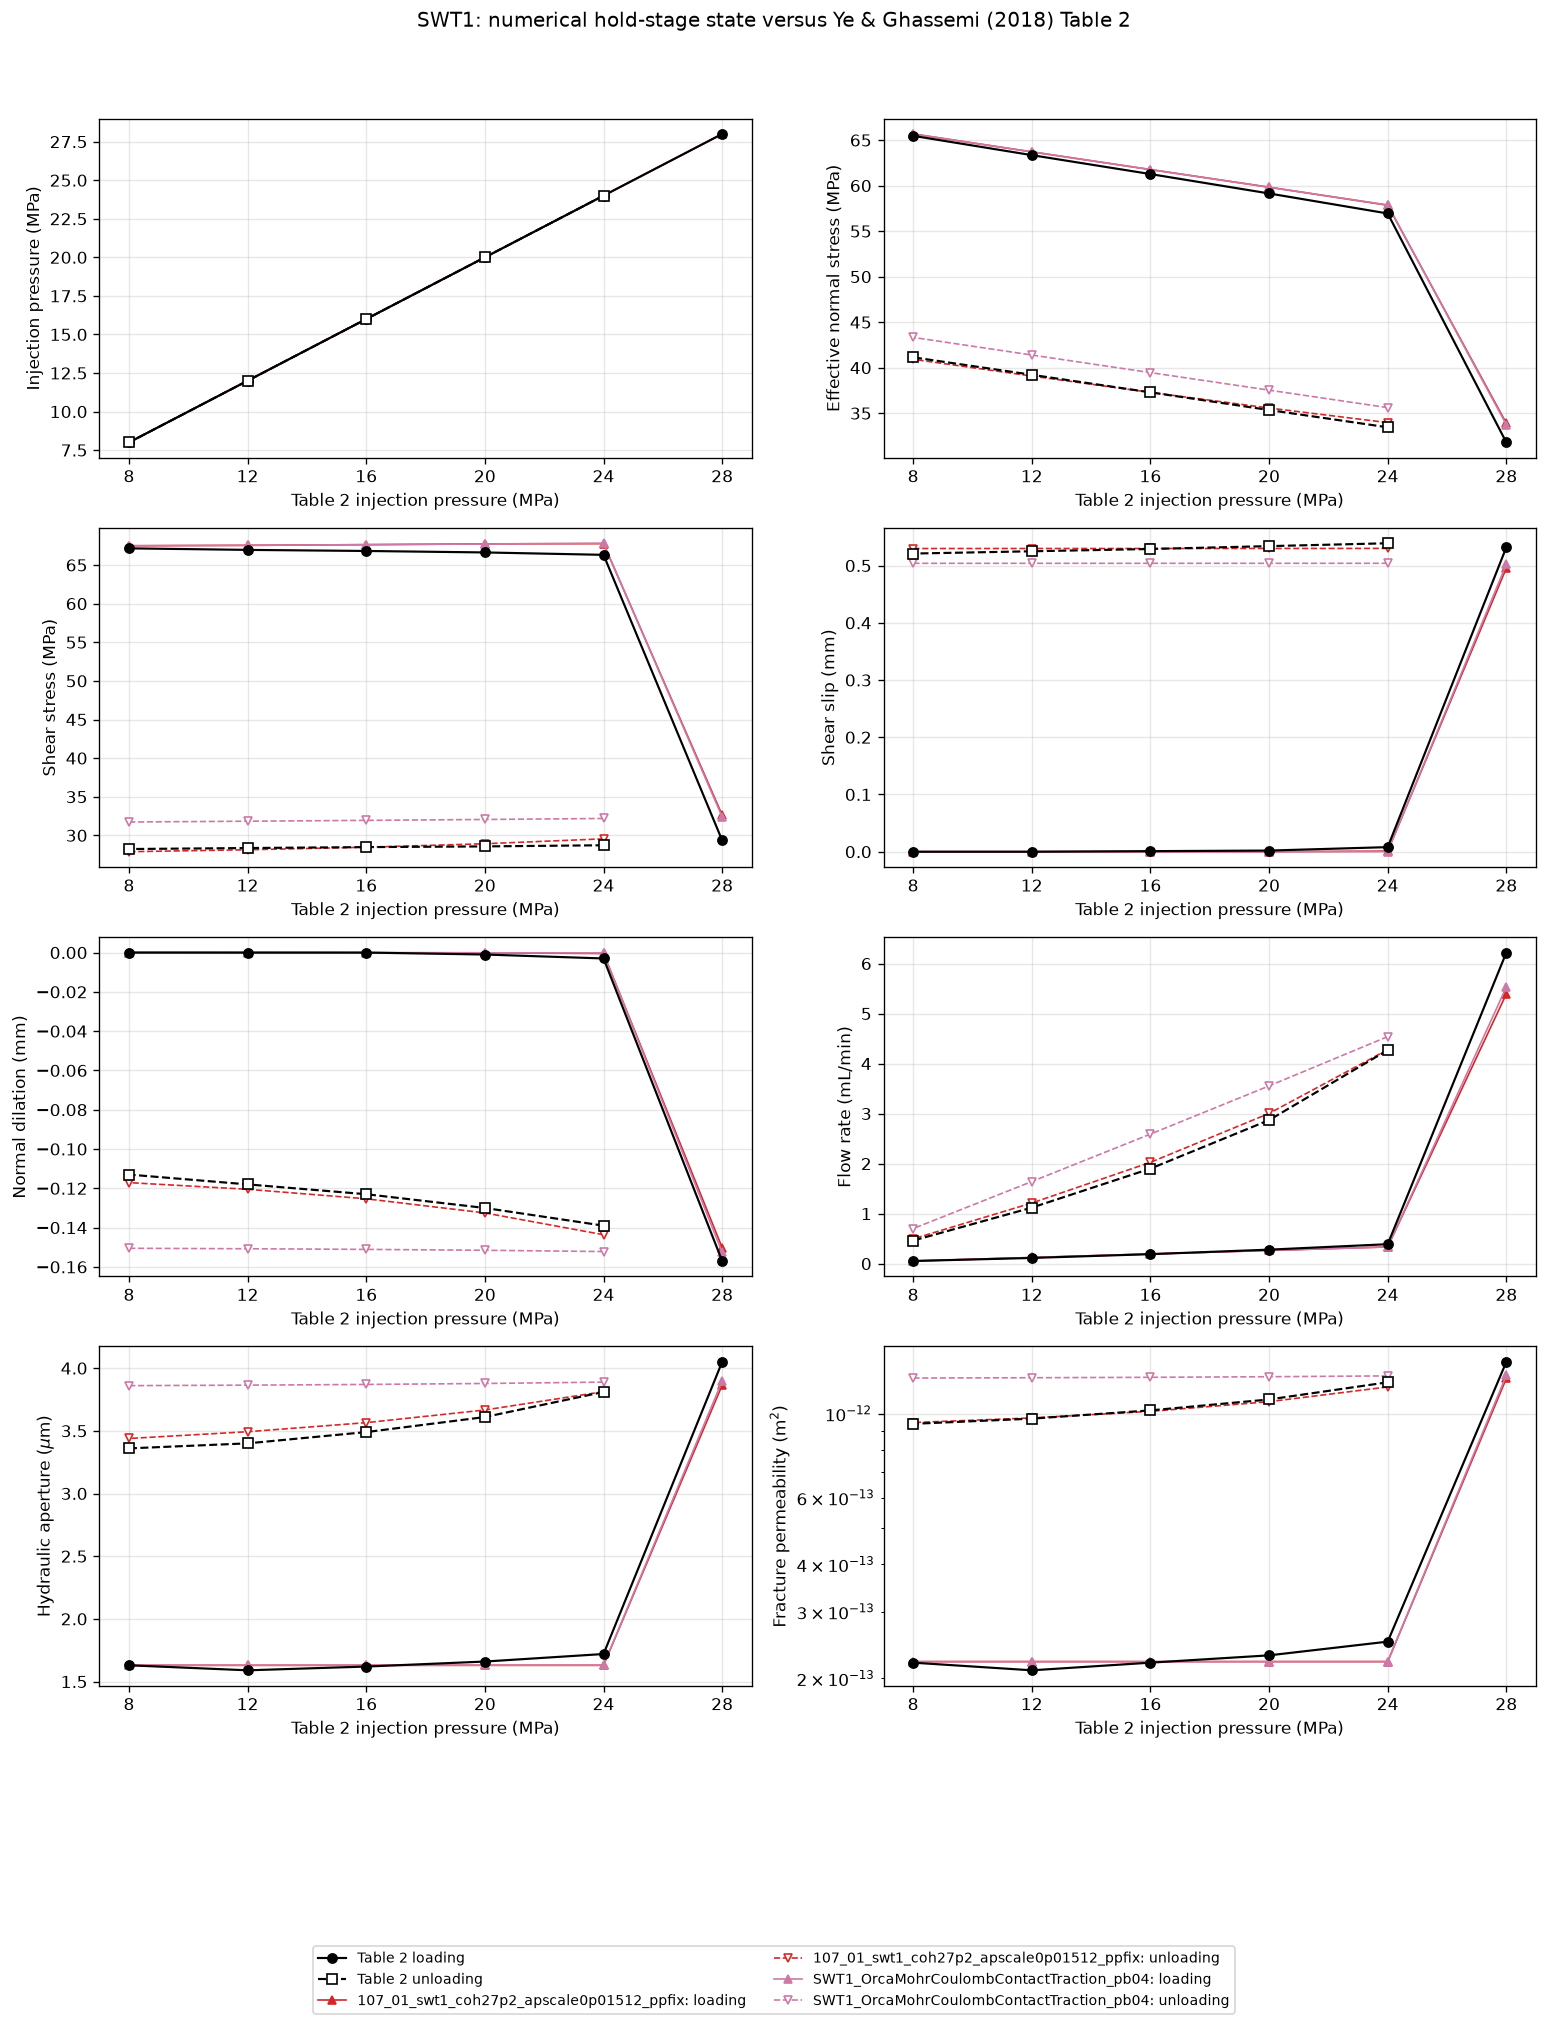

Table 2 source: /media/geomechanics/Data4TB/projects/orca_4.0/Examples/YeGhasemmi2018/Output_Image_Comparison/Extracted_Data/Table2_4_Sample_CSV_Files/SW-T1_Table2.csv
Table 2 comparison figure: /media/geomechanics/Data4TB/projects/orca_4.0/Examples/YeGhasemmi2018/SWT1/Ye2018_SWT1_Table2_hold_stage_comparison.png


,case,quantity,model_source,unit,stages_compared,rmse,mae,bias
0,107_01_swt1_coh27p2_apscale0p01512_ppfix,injection_pressure,injection_pressure_pp,MPa,11,0.000000e+00,0.000000e+00,0.000000e+00
1,107_01_swt1_coh27p2_apscale0p01512_ppfix,effective_normal_stress,effective_normal_paper_frame_mpa_pp,MPa,11,7.691175e-01,5.317840e-01,4.666003e-01
2,107_01_swt1_coh27p2_apscale0p01512_ppfix,shear_stress,shear_stress_paper_frame_mpa_pp,MPa,11,1.214151e+00,8.497706e-01,7.432330e-01
3,107_01_swt1_coh27p2_apscale0p01512_ppfix,shear_slip,czm_shear_slip_mm_pp,mm,11,1.197432e-02,6.718913e-03,-4.081955e-03
4,107_01_swt1_coh27p2_apscale0p01512_ppfix,normal_dilation,frac_normal_dilation_paper_mm,mm,11,3.156528e-03,2.398225e-03,-5.446121e-04
5,107_01_swt1_coh27p2_apscale0p01512_ppfix,flow_rate,flow_rate_validation_ml_min_pp,mL/min,11,2.578925e-01,1.185792e-01,-4.478690e-02
6,107_01_swt1_coh27p2_apscale0p01512_ppfix,hydraulic_aperture,hydraulic_aperture_pp,$\mu$m,11,7.915676e-02,6.013453e-02,4.520000e-03
7,107_01_swt1_coh27p2_apscale0p01512_ppfix,fracture_permeability,fracture_permeability_pp,m$^2$,11,4.238434e-14,2.264164e-14,-1.793066e-14
8,SWT1_OrcaMohrCoulombContactTraction_pb04,injection_pressure,injection_pressure_pp,MPa,11,0.000000e+00,0.000000e+00,0.000000e+00
9,SWT1_OrcaMohrCoulombContactTraction_pb04,effective_normal_stress,effective_normal_paper_frame_mpa_pp,MPa,11,1.629413e+00,1.409172e+00,1.409172e+00


In [7]:
# Table 2 source and hold-stage timing (same time basis as the plots above).
TABLE2_FILENAME = 'SW-T1_Table2.csv'
TABLE2_PATH = BASE.parent / 'Output_Image_Comparison' / 'Extracted_Data' / 'Table2_4_Sample_CSV_Files' / TABLE2_FILENAME
TABLE2_HOLD_TIMES_S = np.array([225.2, 556.9, 838.6, 1164.2, 1436.6, 1704.7, 2063.5, 2336.9, 2629.0, 2952.2, 3256.8], dtype=float)

if not TABLE2_PATH.is_file():
    raise FileNotFoundError(f'Table 2 CSV not found: {TABLE2_PATH}')

table2 = pd.read_csv(TABLE2_PATH)
required_table2_columns = {
    'hold_stage_index', 'segment', 'injection_pressure_MPa',
    'flow_rate_ml_min', 'normal_dilation_mm', 'shear_slip_mm',
    'effective_normal_stress_MPa', 'shear_stress_MPa',
    'hydraulic_aperture_m', 'fracture_permeability_m2',
}
missing_table2_columns = sorted(required_table2_columns.difference(table2.columns))
if missing_table2_columns:
    raise KeyError(f'{TABLE2_PATH.name}: missing columns {missing_table2_columns}')
if len(table2) != len(TABLE2_HOLD_TIMES_S):
    raise ValueError(
        f'{TABLE2_PATH.name}: expected {len(TABLE2_HOLD_TIMES_S)} hold stages, '
        f'found {len(table2)}'
    )

table2 = table2.copy().sort_values('hold_stage_index').reset_index(drop=True)
table2['hold_time_s'] = TABLE2_HOLD_TIMES_S
table2['branch'] = table2['segment'].str.strip().str.lower()

# key: (Table 2 column, model alias/column, model scale, displayed scale, label, unit)
TABLE2_PANEL_SPECS = {
    'injection_pressure': (
        'injection_pressure_MPa', 'injection_pressure_pa', 1.0e-6, 1.0,
        'Injection pressure', 'MPa',
    ),
    'effective_normal_stress': (
        'effective_normal_stress_MPa', 'effective_normal_paper_frame_mpa', 1.0, 1.0,
        'Effective normal stress', 'MPa',
    ),
    'shear_stress': (
        'shear_stress_MPa', 'shear_stress_paper_frame_mpa', 1.0, 1.0,
        'Shear stress', 'MPa',
    ),
    'shear_slip': (
        'shear_slip_mm', 'shear_slip_paper_mm', 1.0, 1.0,
        'Shear slip', 'mm',
    ),
    'normal_dilation': (
        'normal_dilation_mm', 'normal_dilation_paper_mm', 1.0, 1.0,
        'Normal dilation', 'mm',
    ),
    'flow_rate': (
        'flow_rate_ml_min', 'flow_rate_ml_min', 1.0, 1.0,
        'Flow rate', 'mL/min',
    ),
    'hydraulic_aperture': (
        'hydraulic_aperture_m', 'hydraulic_aperture_m', 1.0, 1.0e6,
        'Hydraulic aperture', r'$\mu$m',
    ),
    'fracture_permeability': (
        'fracture_permeability_m2', 'fracture_permeability_m2', 1.0, 1.0,
        'Fracture permeability', r'm$^2$',
    ),
}


def table2_model_series(data, alias_or_column, scale=1.0):
    df = data['df']
    if alias_or_column in df.columns:
        values = pd.to_numeric(df[alias_or_column], errors='coerce') * scale
        source = alias_or_column
    else:
        values, source = first_series(df, alias_or_column, case_name=data['name'])
        if values is not None:
            values = values * scale
    if values is None:
        return None, source
    valid = pd.DataFrame({
        'time': pd.to_numeric(df['time'], errors='coerce'),
        'value': pd.to_numeric(values, errors='coerce'),
    }).dropna().sort_values('time').drop_duplicates('time', keep='last')
    return valid, source


def sample_table2_holds(data, alias_or_column, scale=1.0):
    valid, source = table2_model_series(data, alias_or_column, scale)
    if valid is None or valid.empty:
        return np.full(len(TABLE2_HOLD_TIMES_S), np.nan), source
    sampled = np.interp(
        TABLE2_HOLD_TIMES_S,
        valid['time'].to_numpy(float),
        valid['value'].to_numpy(float),
        left=np.nan,
        right=np.nan,
    )
    return sampled, source


table2_case_frames = {}
table2_metric_rows = []
for case_name, data in loaded_cases.items():
    comparison = table2[[
        'hold_stage_index', 'branch', 'injection_pressure_MPa', 'hold_time_s'
    ]].copy()
    for quantity, spec in TABLE2_PANEL_SPECS.items():
        table_column, model_alias, model_scale, display_scale, _label, unit = spec
        model_values, source = sample_table2_holds(data, model_alias, model_scale)
        paper_values = pd.to_numeric(table2[table_column], errors='coerce').to_numpy(float)
        # Table 2 reports displacements relative to the first hold; match the authoritative scorer.
        if quantity in {'normal_dilation', 'shear_slip'}:
            model_values = model_values - model_values[0]
            paper_values = paper_values - paper_values[0]
        model_values = model_values * display_scale
        paper_values = paper_values * display_scale
        comparison[f'{quantity}_model'] = model_values
        comparison[f'{quantity}_table2'] = paper_values
        comparison[f'{quantity}_error'] = model_values - paper_values
        valid_error = comparison[f'{quantity}_error'].dropna().to_numpy(float)
        if len(valid_error):
            table2_metric_rows.append({
                'case': case_name,
                'quantity': quantity,
                'model_source': source or 'unavailable',
                'unit': unit,
                'stages_compared': int(len(valid_error)),
                'rmse': float(np.sqrt(np.mean(valid_error**2))),
                'mae': float(np.mean(np.abs(valid_error))),
                'bias': float(np.mean(valid_error)),
            })
    table2_case_frames[case_name] = comparison

fig, axes = plt.subplots(4, 2, figsize=(13, 17), squeeze=False)
branch_styles = {
    'loading': dict(marker='^', linestyle='-'),
    'unloading': dict(marker='v', linestyle='--'),
}
case_colors = {
    case_name: data['cfg'].get('color', f'C{index}')
    for index, (case_name, data) in enumerate(loaded_cases.items())
}

for ax, (quantity, spec) in zip(axes.flat, TABLE2_PANEL_SPECS.items()):
    table_column, _model_alias, _model_scale, display_scale, label, unit = spec
    for branch, paper_marker, paper_fill in (
        ('loading', 'o', 'black'), ('unloading', 's', 'white')
    ):
        paper = table2.loc[table2['branch'].eq(branch)]
        ax.plot(
            paper['injection_pressure_MPa'],
            pd.to_numeric(paper[table_column], errors='coerce') * display_scale,
            color='black', marker=paper_marker, markerfacecolor=paper_fill,
            linestyle='-' if branch == 'loading' else '--', linewidth=1.3,
            markersize=5.5, label=f'Table 2 {branch}', zorder=6,
        )
    for case_name, comparison in table2_case_frames.items():
        color = case_colors[case_name]
        for branch, style in branch_styles.items():
            model = comparison.loc[comparison['branch'].eq(branch)]
            ax.plot(
                model['injection_pressure_MPa'], model[f'{quantity}_model'],
                color=color, markerfacecolor=color if branch == 'loading' else 'white',
                markeredgecolor=color, linewidth=1.0, markersize=5,
                label=f'{case_name}: {branch}', **style,
            )
    ax.set_xlabel('Table 2 injection pressure (MPa)')
    ax.set_ylabel(f'{label} ({unit})')
    ax.set_xticks([8, 12, 16, 20, 24, 28])
    if quantity == 'fracture_permeability':
        ax.set_yscale('log')

fig.suptitle(
    f'{SAMPLE}: numerical hold-stage state versus Ye & Ghassemi (2018) Table 2',
    y=0.995,
)
place_bottom_legend(fig, axes, ncol=2, bottom=0.14, top=0.97)
table2_figure_path = BASE / f'Ye2018_{SAMPLE}_Table2_hold_stage_comparison.png'
fig.savefig(table2_figure_path, bbox_inches='tight')
plt.show()

table2_metrics = pd.DataFrame(table2_metric_rows)
print(f'Table 2 source: {TABLE2_PATH}')
print(f'Table 2 comparison figure: {table2_figure_path}')
with pd.option_context('display.max_rows', 200, 'display.max_columns', None):
    display(table2_metrics)


In [8]:
# # 1. Accepted timestep versus time, with validation-event zoom.
# fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
# plot_metric(axes[0], 'accepted_dt_s', 'accepted dt (s)', yscale='log')
# axes[0].set_title('Accepted timestep')
# plot_metric(axes[1], 'accepted_dt_s', 'accepted dt (s)', yscale='log')
# axes[1].set_xlim(*EVENT_WINDOW_S)
# axes[1].axvline(EVENT_TIME_S, color='k', linewidth=1, alpha=0.5)
# axes[1].set_title(f'Zoom: {EVENT_WINDOW_S[0]:g}-{EVENT_WINDOW_S[1]:g} s')
# place_bottom_legend(fig, axes, ncol=1, bottom=0.25)
# fig.savefig(BASE / 'Ye2018_SWT1_pressure_coupling_dt.png', bbox_inches='tight')
# plt.show()

# # 2. Injection pressure and interface pore pressure.
# fig, ax = plt.subplots(figsize=(8, 4))
# for name, data in loaded_cases.items():
#     df = data['df']
#     cfg = data['cfg']
#     inj, inj_col = first_series(df, 'injection_pressure_pa')
#     pif, pif_col = first_series(df, 'interface_pore_pressure_pa')
#     if inj is not None:
#         ax.plot(df['time'], inj / 1.0e6, linestyle=cfg['style'], color=cfg['color'], linewidth=1.5, label=f'{name}: injection')
#     if pif is not None:
#         ax.plot(df['time'], pif / 1.0e6, linestyle=':', color=cfg['color'], linewidth=1.2, label=f'{name}: interface pore pressure')
# ax.set_xlabel('time (s)')
# ax.set_ylabel('pressure (MPa)')
# place_bottom_legend(fig, ax, ncol=1, bottom=0.32)
# fig.savefig(BASE / 'Ye2018_SWT1_pressure_coupling_pressures.png', bbox_inches='tight')
# plt.show()

# # 3. Contact normal stress and BB effective normal stress.
# fig, ax = plt.subplots(figsize=(8, 4))
# for name, data in loaded_cases.items():
#     df = data['df']
#     cfg = data['cfg']
#     normal, _ = first_series(df, 'bb_normal_stress_pa')
#     effective, _ = first_series(df, 'bb_effective_normal_stress_pa')
#     if normal is not None:
#         ax.plot(df['time'], normal / 1.0e6, linestyle=cfg['style'], color=cfg['color'], linewidth=1.4, label=f'{name}: BB normal')
#     if effective is not None:
#         ax.plot(df['time'], effective / 1.0e6, linestyle=':', color=cfg['color'], linewidth=1.2, label=f'{name}: BB effective normal')
# ax.set_xlabel('time (s)')
# ax.set_ylabel('stress (MPa)')
# place_bottom_legend(fig, ax, ncol=1, bottom=0.32)
# fig.savefig(BASE / 'Ye2018_SWT1_pressure_coupling_normal_stress.png', bbox_inches='tight')
# plt.show()

In [9]:
# # 4. Shear traction magnitude and BB shear-strength limit.
# fig, ax = plt.subplots(figsize=(8, 4))
# for name, data in loaded_cases.items():
#     df = data['df']
#     cfg = data['cfg']
#     shear = df.get('shear_traction_magnitude_pa')
#     limit_tau, _ = first_series(df, 'bb_limit_tau_pa')
#     if shear is not None:
#         ax.plot(df['time'], shear / 1.0e6, linestyle=cfg['style'], color=cfg['color'], linewidth=1.4, label=f'{name}: shear traction')
#     if limit_tau is not None:
#         ax.plot(df['time'], limit_tau / 1.0e6, linestyle=':', color=cfg['color'], linewidth=1.2, label=f'{name}: BB limit')
# ax.set_xlabel('time (s)')
# ax.set_ylabel('shear stress / strength (MPa)')
# place_bottom_legend(fig, ax, ncol=1, bottom=0.32)
# fig.savefig(BASE / 'Ye2018_SWT1_pressure_coupling_shear_limit.png', bbox_inches='tight')
# plt.show()

# # 5. Shear-strength margin, with validation-event zoom.
# fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
# plot_metric(axes[0], 'strength_margin_pa', 'BB strength margin (Pa)')
# axes[0].axhline(0.0, color='k', linewidth=1, alpha=0.5)
# axes[0].set_title('Strength margin')
# plot_metric(axes[1], 'strength_margin_pa', 'BB strength margin (Pa)')
# axes[1].set_xlim(*EVENT_WINDOW_S)
# axes[1].axhline(0.0, color='k', linewidth=1, alpha=0.5)
# axes[1].axvline(EVENT_TIME_S, color='k', linewidth=1, alpha=0.5)
# axes[1].set_title(f'Zoom: {EVENT_WINDOW_S[0]:g}-{EVENT_WINDOW_S[1]:g} s')
# place_bottom_legend(fig, axes, ncol=1, bottom=0.25)
# fig.savefig(BASE / 'Ye2018_SWT1_pressure_coupling_strength_margin.png', bbox_inches='tight')
# plt.show()

# # 6. Hydraulic aperture.
# fig, ax = plt.subplots(figsize=(8, 4))
# plot_metric(ax, 'hydraulic_aperture_m', 'hydraulic aperture (m)')
# place_bottom_legend(fig, ax, ncol=1, bottom=0.25)
# fig.savefig(BASE / 'Ye2018_SWT1_pressure_coupling_aperture.png', bbox_inches='tight')
# plt.show()

# # 7. Fracture permeability and transmissivity.
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# plot_metric(axes[0], 'fracture_permeability_m2', 'fracture permeability (m$^2$)', yscale='log')
# plot_metric(axes[1], 'fracture_transmissivity_m3_pa_s', 'fracture transmissivity (m$^3$/(Pa s))', yscale='log')
# place_bottom_legend(fig, axes, ncol=1, bottom=0.25)
# fig.savefig(BASE / 'Ye2018_SWT1_pressure_coupling_hydraulic_properties.png', bbox_inches='tight')
# plt.show()

# # 8. Nonlinear iterations or solver diagnostics, if available.
# fig, ax = plt.subplots(figsize=(8, 4))
# plotted_iterations = plot_metric(ax, 'nonlinear_iterations', 'nonlinear iterations')
# if plotted_iterations:
#     place_bottom_legend(fig, ax, ncol=1, bottom=0.25)
#     fig.savefig(BASE / 'Ye2018_SWT1_pressure_coupling_nonlinear_iterations.png', bbox_inches='tight')
#     plt.show()
# else:
#     plt.close(fig)
#     print('No nonlinear-iteration postprocessor column was available in the loaded CSV files.')

In [10]:
# # Quantitative mismatch metrics and slip-onset zoom.
# def interp_series(time, values, query_time):
#     valid = pd.DataFrame({'time': time, 'value': values}).dropna().sort_values('time')
#     if valid.empty or query_time < valid['time'].iloc[0] or query_time > valid['time'].iloc[-1]:
#         return np.nan
#     return float(np.interp(query_time, valid['time'], valid['value']))

# metric_specs = {
#     'differential_stress': ('differential_stress_mpa', 1.0),
#     'injection_pressure': ('injection_pressure_pa', 1.0e-6),
#     'flow_rate': ('flow_rate_ml_min', 1.0),
#     'frac_perm': ('fracture_permeability_m2', 1.0),
#     'normal_dilation': ('normal_dilation_mm', 1.0),
#     'normal_stress': ('bb_effective_normal_stress_pa', 1.0e-6),
#     'shear_slip': ('shear_slip_mm', 1.0),
#     'shear_stress': ('shear_traction_magnitude_pa', 1.0e-6),
# }

# metric_rows = []
# for case_name, data in loaded_cases.items():
#     df = data['df']
#     for val_key, (alias, scale) in metric_specs.items():
#         vdf = validation.get(val_key)
#         if vdf is None or vdf.empty:
#             continue
#         if alias in df.columns:
#             model_values = df[alias] * scale
#         else:
#             series, _ = first_series(df, alias)
#             if series is None:
#                 continue
#             model_values = series * scale
#         errors = []
#         for t_val, y_val in zip(vdf['time_s'], vdf['value']):
#             y_model = interp_series(df['time'], model_values, t_val)
#             if np.isfinite(y_model):
#                 errors.append(y_model - y_val)
#         if errors:
#             errors = np.asarray(errors, dtype=float)
#             metric_rows.append({
#                 'case': case_name,
#                 'quantity': val_key,
#                 'n': int(len(errors)),
#                 'rmse': float(np.sqrt(np.mean(errors**2))),
#                 'mae': float(np.mean(np.abs(errors))),
#                 'bias': float(np.mean(errors)),
#             })

# metrics = pd.DataFrame(metric_rows)
# with pd.option_context('display.max_rows', 200, 'display.max_columns', None):
#     display(metrics)

# def onset_time_from_xy(time, values, *, baseline_end=EVENT_BASELINE_END_S, threshold=0.002, direction='increase'):
#     xy = pd.DataFrame({'time': time, 'value': values}).dropna().sort_values('time')
#     early = xy.loc[xy['time'] <= baseline_end, 'value']
#     baseline = float(early.median()) if not early.empty else float(xy['value'].iloc[0])
#     for _, row in xy.loc[xy['time'] >= baseline_end].iterrows():
#         delta = row['value'] - baseline
#         if direction == 'increase' and delta >= threshold:
#             return float(row['time'])
#         if direction == 'decrease' and -delta >= threshold:
#             return float(row['time'])
#     return np.nan

# onset_rows = []
# val_slip_onset = onset_time_from_xy(validation['shear_slip']['time_s'], validation['shear_slip']['value'], threshold=0.002, direction='increase')
# val_dilation_onset = onset_time_from_xy(validation['normal_dilation']['time_s'], validation['normal_dilation']['value'], threshold=0.002, direction='decrease')
# val_stress_drop_onset = onset_time_from_xy(validation['differential_stress']['time_s'], validation['differential_stress']['value'], threshold=2.0, direction='decrease')
# for case_name, data in loaded_cases.items():
#     df = data['df']
#     slip, _ = first_series(df, 'shear_slip_mm')
#     dilation, _ = first_series(df, 'normal_dilation_mm')
#     diff, _ = first_series(df, 'differential_stress_mpa')
#     onset_rows.append({
#         'case': case_name,
#         'validation_slip_onset_s': val_slip_onset,
#         'model_slip_onset_s': onset_time_from_xy(df['time'], slip, threshold=0.002, direction='increase') if slip is not None else np.nan,
#         'validation_dilation_onset_s': val_dilation_onset,
#         'model_dilation_onset_s': onset_time_from_xy(df['time'], dilation, threshold=0.002, direction='decrease') if dilation is not None else np.nan,
#         'validation_stress_drop_onset_s': val_stress_drop_onset,
#         'model_stress_drop_onset_s': onset_time_from_xy(df['time'], diff, threshold=2.0, direction='decrease') if diff is not None else np.nan,
#     })
# onsets = pd.DataFrame(onset_rows)
# display(onsets)

# fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
# zoom = EVENT_WINDOW_S
# plot_items = [
#     ('shear_slip', 'shear_slip_mm', 'Shear slip (mm)'),
#     ('normal_dilation', 'normal_dilation_mm', 'Normal dilation (mm)'),
#     ('differential_stress', 'differential_stress_mpa', 'Differential stress (MPa)'),
# ]
# for ax, (val_key, alias, ylabel) in zip(axes, plot_items):
#     vdf = validation[val_key]
#     ax.plot(vdf['time_s'], vdf['value'], 'o', ms=3, color='tab:orange', label='Ye & Ghassemi digitized')
#     plot_case_lines(ax, alias)
#     ax.set_xlim(*zoom)
#     ax.set_ylabel(ylabel)
# axes[-1].set_xlabel('time (s)')
# fig.suptitle('Slip-onset zoom')
# place_bottom_legend(fig, axes, ncol=1, bottom=0.12, top=0.94)
# fig.savefig(BASE / 'Ye2018_SWT1_pressure_coupling_slip_onset_zoom.png', bbox_inches='tight')
# plt.show()

In [11]:
print(f'{SAMPLE} validation coverage')
print('-' * (len(SAMPLE) + 20))
print(f'Validation data extend to {VALIDATION_END_TIME_S:.3f} s.')
print(f'Major measured transition is assessed over {EVENT_WINDOW_S[0]:.1f}-{EVENT_WINDOW_S[1]:.1f} s.')
for row in summary.to_dict('records'):
    status = 'complete' if row['reached_validation_end'] else 'partial'
    print(
        f"{row['case']}: {status} validation coverage "
        f"(simulation {row['final_time_s']:.3f} s; validation criterion {VALIDATION_END_TIME_S:.3f} s)."
    )


SWT1 validation coverage
------------------------
Validation data extend to 3370.000 s.
Major measured transition is assessed over 1600.0-1875.0 s.
107_01_swt1_coh27p2_apscale0p01512_ppfix: complete validation coverage (simulation 3499.841 s; validation criterion 3370.000 s).
SWT1_OrcaMohrCoulombContactTraction_pb04: complete validation coverage (simulation 3500.000 s; validation criterion 3370.000 s).


## Reproducibility notes

Run this notebook from the `SWT1` directory. It reads digitized validation data
from `SWT1/`, simulation time histories from `results_csv/`, and matching input
decks from the current directory. Result CSV files without a `time` column (for
example, Table-2 summaries) are intentionally excluded from the time-history plots.


## Individual validation and Table 2 figures for every HPC file

Every CSV in `results_csv_hpc*` is shown individually, including files that are not
enabled in the comparison dictionary above. Files are processed in filename order.
For each file, the time-history comparison against the digitized validation is drawn
first, immediately followed by the hold-stage comparison against Table 2. Only then
does the notebook move to the next HPC file.


In [12]:
# def discover_ordered_hpc_files():
#     """Discover every HPC CSV and return it in deterministic filename order."""
#     roots = [Path(HPC_RESULTS)]
#     files = {
#         path.resolve(): path.resolve()
#         for root in roots if root.is_dir()
#         for path in root.glob('*.csv')
#         if path.is_file()
#     }
#     return sorted(files.values(), key=lambda path: path.name.lower())


# def read_hpc_validation_file(path):
#     frame = pd.read_csv(path)
#     if 'time' not in frame.columns:
#         raise KeyError(f'{path.name}: missing required time column')
#     for column in frame.columns:
#         frame[column] = pd.to_numeric(frame[column], errors='coerce')
#     frame = (
#         frame.dropna(subset=['time'])
#         .sort_values('time')
#         .drop_duplicates('time', keep='last')
#         .reset_index(drop=True)
#     )

#     # Recreate the derived shear-traction channel used by the combined figure above.
#     tau1 = frame.get('czm_tau_1_pp')
#     tau2 = frame.get('czm_tau_2_pp')
#     if tau1 is not None and tau2 is not None:
#         frame['shear_traction_magnitude_pa'] = np.sqrt(tau1**2 + tau2**2)
#     elif tau1 is not None:
#         frame['shear_traction_magnitude_pa'] = tau1.abs()
#     elif 'shear_traction_magnitude_pa' not in frame:
#         shear_mpa, _ = first_series(frame, 'shear_stress_mpa', case_name=path.stem)
#         frame['shear_traction_magnitude_pa'] = (
#             shear_mpa.abs() * 1.0e6 if shear_mpa is not None else np.nan
#         )
#     return frame


# def individual_model_values(frame, alias_or_column, scale=1.0):
#     if alias_or_column in frame.columns:
#         return pd.to_numeric(frame[alias_or_column], errors='coerce') * scale
#     values, _ = first_series(frame, alias_or_column)
#     return None if values is None else values * scale


# def plot_individual_time_history(hpc_path, frame):
#     """First figure: the same eight validation panels, for one HPC file only."""
#     fig, axes = plt.subplots(4, 2, figsize=(12, 16), squeeze=False)
#     for ax, spec in zip(axes.flat, panel_specs):
#         validation_key, model_alias, ylabel = spec[:3]
#         scale = spec[3] if len(spec) > 3 else 1.0
#         yscale = spec[4] if len(spec) > 4 else None

#         measured = validation.get(validation_key)
#         if measured is not None and not measured.empty:
#             ax.plot(
#                 measured['time_s'], measured['value'], 'o', markersize=3,
#                 color='tab:orange', label='Ye & Ghassemi digitized', zorder=5,
#             )
#         model_values = individual_model_values(frame, model_alias, scale)
#         if model_values is not None:
#             ax.plot(
#                 frame['time'], model_values, color='tab:blue', linewidth=1.5,
#                 label=hpc_path.stem,
#             )
#         else:
#             ax.text(
#                 0.5, 0.5, f'Missing model channel: {model_alias}',
#                 transform=ax.transAxes, ha='center', va='center',
#             )
#         ax.set_xlabel('time (s)')
#         ax.set_ylabel(ylabel)
#         if yscale:
#             ax.set_yscale(yscale)

#     fig.suptitle(
#         f'{SAMPLE}: {hpc_path.name}\n'
#         'digitized validation and pressure-coupling result',
#         y=0.995,
#     )
#     place_bottom_legend(fig, axes, ncol=1, bottom=0.075, top=0.95)
#     plt.show()
#     plt.close(fig)
#     return fig


# def plot_individual_table2(hpc_path, frame):
#     """Second figure: the same eight Table 2 panels, for one HPC file only."""
#     data = {'name': hpc_path.stem, 'df': frame}
#     comparison = table2[[
#         'hold_stage_index', 'branch', 'injection_pressure_MPa', 'hold_time_s'
#     ]].copy()
#     for quantity, spec in TABLE2_PANEL_SPECS.items():
#         _table_column, model_alias, model_scale, display_scale, _label, _unit = spec
#         values, _ = sample_table2_holds(data, model_alias, model_scale)
#         comparison[f'{quantity}_model'] = values * display_scale

#     fig, axes = plt.subplots(4, 2, figsize=(13, 17), squeeze=False)
#     for ax, (quantity, spec) in zip(axes.flat, TABLE2_PANEL_SPECS.items()):
#         table_column, _model_alias, _model_scale, display_scale, label, unit = spec
#         for branch, paper_marker, paper_fill in (
#             ('loading', 'o', 'black'), ('unloading', 's', 'white')
#         ):
#             paper = table2.loc[table2['branch'].eq(branch)]
#             ax.plot(
#                 paper['injection_pressure_MPa'],
#                 pd.to_numeric(paper[table_column], errors='coerce') * display_scale,
#                 color='black', marker=paper_marker, markerfacecolor=paper_fill,
#                 linestyle='-' if branch == 'loading' else '--', linewidth=1.3,
#                 markersize=5.5, label=f'Table 2 {branch}', zorder=6,
#             )

#         for branch, marker, linestyle, fill in (
#             ('loading', '^', '-', 'tab:blue'),
#             ('unloading', 'v', '--', 'white'),
#         ):
#             model = comparison.loc[comparison['branch'].eq(branch)]
#             ax.plot(
#                 model['injection_pressure_MPa'], model[f'{quantity}_model'],
#                 color='tab:blue', marker=marker, markerfacecolor=fill,
#                 markeredgecolor='tab:blue', linestyle=linestyle,
#                 linewidth=1.1, markersize=5,
#                 label=f'{hpc_path.stem}: {branch}',
#             )
#         ax.set_xlabel('Table 2 injection pressure (MPa)')
#         ax.set_ylabel(f'{label} ({unit})')
#         ax.set_xticks([8, 12, 16, 20, 24, 28])
#         if quantity == 'fracture_permeability':
#             ax.set_yscale('log')

#     fig.suptitle(
#         f'{SAMPLE}: {hpc_path.name}\n'
#         'numerical hold-stage state versus Ye & Ghassemi (2018) Table 2',
#         y=0.995,
#     )
#     place_bottom_legend(fig, axes, ncol=2, bottom=0.10, top=0.95)
#     plt.show()
#     plt.close(fig)
#     return fig


# ORDERED_HPC_RESULT_FILES = discover_ordered_hpc_files()
# print(f'Found {len(ORDERED_HPC_RESULT_FILES)} HPC result file(s).')
# print('Display order: time-history figure, then Table 2 figure, for each file.')

# individual_hpc_rows = []
# for file_number, hpc_path in enumerate(ORDERED_HPC_RESULT_FILES, start=1):
#     print('\n' + '=' * 100)
#     print(f'{file_number}/{len(ORDERED_HPC_RESULT_FILES)}: {hpc_path.name}')
#     try:
#         hpc_frame = read_hpc_validation_file(hpc_path)
#         # Required order for each file:
#         plot_individual_time_history(hpc_path, hpc_frame)
#         plot_individual_table2(hpc_path, hpc_frame)
#         individual_hpc_rows.append({
#             'order': file_number,
#             'file': hpc_path.name,
#             'rows': int(len(hpc_frame)),
#             'final_time_s': float(hpc_frame['time'].max()),
#             'time_history_figure': 'drawn first',
#             'table2_figure': 'drawn second',
#             'status': 'OK',
#         })
#     except Exception as exc:
#         warnings.warn(f'Could not plot {hpc_path}: {exc}')
#         individual_hpc_rows.append({
#             'order': file_number,
#             'file': hpc_path.name,
#             'rows': 0,
#             'final_time_s': np.nan,
#             'time_history_figure': 'not drawn',
#             'table2_figure': 'not drawn',
#             'status': f'ERROR: {exc}',
#         })
#     finally:
#         if 'hpc_frame' in locals():
#             del hpc_frame

# INDIVIDUAL_HPC_SUMMARY = pd.DataFrame(individual_hpc_rows)
# display(INDIVIDUAL_HPC_SUMMARY)


## Completed MC sweep: authoritative Table 2 ranking

This final check scores only cases explicitly present in `cases`. It uses the five independent Table 2 observables, the stage-1 displacement datum, and the common kinematic normal jump. Derived hydraulic aperture and permeability remain plotted above but are not counted twice in the headline score.


In [13]:
import sys

PROJECT_ROOT = BASE.parents[2]
if str(PROJECT_ROOT / 'scripts') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))
import table2_gate

authoritative_rows = []
for case_name, cfg in selected_cases.items():
    if case_name not in loaded_cases:
        continue
    tag = cfg.get('sweep_tag')
    result = table2_gate.score_run(
        cfg['csv'], SAMPLE, tag=tag, tol_mpa=0.15,
        datum='stage1', preload_time=55.0, dn_channel='kinematic',
    )
    scores = table2_gate.normalised_scores(result)
    authoritative_rows.append({
        'case': case_name,
        'kind': cfg.get('kind', 'unspecified'),
        'stages': result['reached'],
        'Q nRMSE (%)': scores.get('Q_ml_min', np.nan),
        'effective normal nRMSE (%)': scores.get('sigma_n_MPa', np.nan),
        'shear stress nRMSE (%)': scores.get('tau_MPa', np.nan),
        'normal displacement nRMSE (%)': scores.get('dn_mm', np.nan),
        'shear displacement nRMSE (%)': scores.get('ds_mm', np.nan),
        'mean nRMSE (%)': scores.get('mean', np.nan),
    })

authoritative_ranking = (
    pd.DataFrame(authoritative_rows)
    .sort_values(['mean nRMSE (%)', 'case'], na_position='last')
    .reset_index(drop=True)
)
display(authoritative_ranking.style.format(precision=3))
mc_authoritative = authoritative_ranking.loc[
    authoritative_ranking['kind'].eq('mc_parameter_sweep')
]
assert len(mc_authoritative) == len(mc_case_names)
assert mc_authoritative['stages'].eq(11).all()
print(f"Best completed MC case: {mc_authoritative.iloc[0]['case']} "
      f"({mc_authoritative.iloc[0]['mean nRMSE (%)']:.3f}% mean nRMSE)")


,case,kind,stages,Q nRMSE (%),effective normal nRMSE (%),shear stress nRMSE (%),normal displacement nRMSE (%),shear displacement nRMSE (%),mean nRMSE (%)
0,107_01_swt1_coh27p2_apscale0p01512_ppfix,series_107_validation,11,1.162,1.458,2.003,1.804,0.939,1.473
1,SWT1_OrcaMohrCoulombContactTraction_pb04,mc_parameter_sweep,11,6.527,4.823,6.656,12.629,3.863,6.900


Best completed MC case: SWT1_OrcaMohrCoulombContactTraction_pb04 (6.900% mean nRMSE)


## Series 108: post-stimulation retention checks

Series 108 extends or changes the paper protocol, so these runs are **diagnostics, not
Table-2 scoring candidates**. The health table keeps every planned arm explicit, including
missing Wave-2 closure-creep CSVs. Controls use a 10-ppm stationarity reporting threshold;
retention arms use a 0.1% endpoint-equivalence threshold. Raw differences are always shown.
Reconfinement is compared at matched effective normal compression with the emitted analytic
virgin backbone, `a_h0 + normal_stress_aperture`. Available closure-creep arms are
checked against an offline integration of their exported stress history.

,mechanism,state,rows,t_end_s,expected_end_s,completion_pct,numeric_finite
run,,,,,,,
108_01_swt1_ctrl_hold1e6,control,complete,8062,1003500.0,1003500.0,100.0,True
108_03_swt1_reconf3p5x,reconfinement,complete,8825,6200.0,6200.0,100.0,True
108_07_swt1_unldtau150,retention lag,complete,8145,63500.0,63500.0,100.0,True
108_08_swt1_unldtau1500,retention lag,complete,8145,63500.0,63500.0,100.0,True
108_09_swt1_unldtau15000,retention lag,complete,8145,63500.0,63500.0,100.0,True
108_11_swt1_creeptc1e5,closure creep,MISSING CSV,0,NaN,1003500.0,NaN,NaN
108_15_swt1_creeptc1e4,closure creep,MISSING CSV,0,NaN,1003500.0,NaN,NaN
108_16_swt1_creeptc1e6,closure creep,MISSING CSV,0,NaN,1003500.0,NaN,NaN


,aperture_start_um,aperture_end_um,aperture_drift_ppm,flow_drift_ppm,plastic_slip_delta_um,stationary_within_10ppm
run,,,,,,
108_01_swt1_ctrl_hold1e6,3.543165,3.543165,0.0,0.0,0.0,True


,state,aperture_delta_um,aperture_delta_pct,flow_delta_pct,normal_stress_delta_MPa,plastic_slip_delta_um,endpoint_within_0p1pct
run,,,,,,,
108_07_swt1_unldtau150,complete,0.000125,0.003528,0.010585,0.0,-0.000615,True
108_08_swt1_unldtau1500,complete,0.035448,1.000453,3.031487,0.0,-0.000631,False
108_09_swt1_unldtau15000,complete,0.411355,11.609819,39.029581,0.0,-0.000633,False


,state,normal_start_MPa,normal_max_MPa,gap_to_virgin_start_um,gap_to_virgin_end_um,minimum_gap_um,crossing_normal_MPa,verdict
run,,,,,,,,
108_03_swt1_reconf3p5x,complete,0.0,0.0,1.913165,1.287061,1.287061,NaN,no crossing in reached range


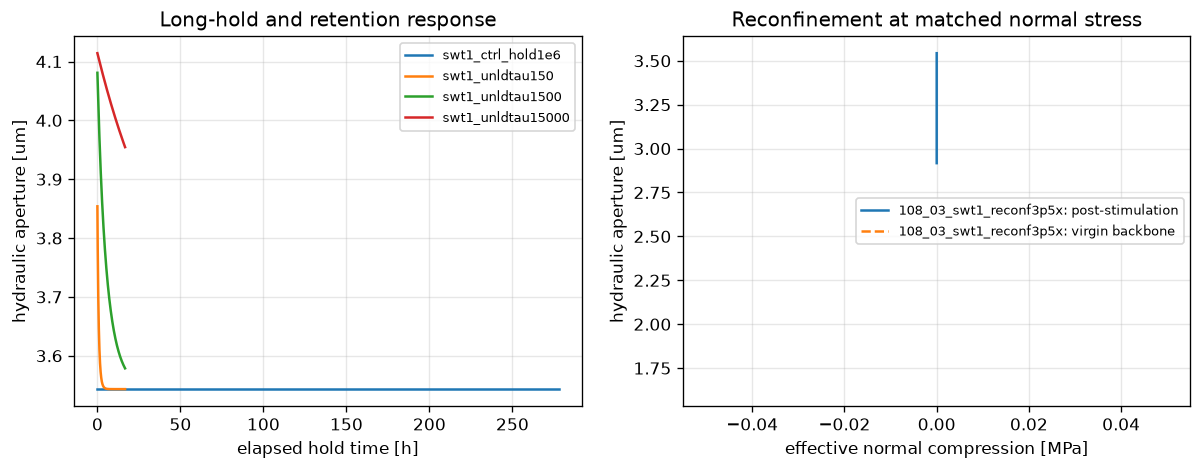

Not interpreted because CSV is missing: 108_11_swt1_creeptc1e5, 108_15_swt1_creeptc1e4, 108_16_swt1_creeptc1e6


In [14]:
SERIES108_RESULT_DIRS = [BASE/'results_csv_hpc_rorqual', SWEEPS/'results_csv_hpc_rorqual']
SERIES108_BY_SAMPLE = {
    'SWT1': {
        '108_01_swt1_ctrl_hold1e6': dict(mechanism='control', protocol_end=3500.0, end_time=1003500.0),
        '108_03_swt1_reconf3p5x': dict(mechanism='reconfinement', protocol_end=3500.0, end_time=6200.0),
        '108_07_swt1_unldtau150': dict(mechanism='retention lag', protocol_end=3500.0, end_time=63500.0, parent='100_01_swt1_vm55um_ppfix_hpc.csv'),
        '108_08_swt1_unldtau1500': dict(mechanism='retention lag', protocol_end=3500.0, end_time=63500.0, parent='100_01_swt1_vm55um_ppfix_hpc.csv'),
        '108_09_swt1_unldtau15000': dict(mechanism='retention lag', protocol_end=3500.0, end_time=63500.0, parent='100_01_swt1_vm55um_ppfix_hpc.csv'),
        '108_11_swt1_creeptc1e5': dict(mechanism='closure creep', protocol_end=3500.0, end_time=1003500.0),
        '108_15_swt1_creeptc1e4': dict(mechanism='closure creep', protocol_end=3500.0, end_time=1003500.0),
        '108_16_swt1_creeptc1e6': dict(mechanism='closure creep', protocol_end=3500.0, end_time=1003500.0),
    },
    'SWT2': {
        '108_04_swt2_reconf3p5x': dict(mechanism='reconfinement', protocol_end=2852.53, end_time=5552.53),
        '108_10_swt2_unldtau1500': dict(mechanism='retention lag', protocol_end=2852.53, end_time=62852.5, parent='100_04_swt2_apscale0p0177_ppfix_hpc.csv'),
        '108_12_swt2_creeptc1e5': dict(mechanism='closure creep', protocol_end=2852.53, end_time=1002852.5),
    },
    'SWS3': {
        '108_05_sw3_reconf3p5x': dict(mechanism='reconfinement', protocol_end=4802.0, end_time=7502.0),
        '108_13_sw3_creeptc1e5': dict(mechanism='closure creep', protocol_end=4802.0, end_time=1004802.0),
    },
    'SWS4': {
        '108_02_sw4_ctrl_hold1e6': dict(mechanism='control', protocol_end=3500.0, end_time=1003500.0),
        '108_06_sw4_reconf3p5x': dict(mechanism='reconfinement', protocol_end=3500.0, end_time=6200.0),
        '108_14_sw4_creeptc1e5': dict(mechanism='closure creep', protocol_end=3500.0, end_time=1003500.0),
    },
}

series108_cfg = SERIES108_BY_SAMPLE[SAMPLE]
series108_data, health_rows = {}, []
for stem, cfg in series108_cfg.items():
    path = next((root/f'{stem}_hpc.csv' for root in SERIES108_RESULT_DIRS
                 if (root/f'{stem}_hpc.csv').exists()), None)
    if path is None:
        health_rows.append(dict(run=stem, mechanism=cfg['mechanism'], state='MISSING CSV',
                                rows=0, t_end_s=np.nan, expected_end_s=cfg['end_time'],
                                completion_pct=np.nan, numeric_finite=np.nan))
        continue
    df = (pd.read_csv(path).sort_values('time')
          .drop_duplicates('time', keep='last').reset_index(drop=True))
    series108_data[stem] = df
    t_end = float(df.time.iloc[-1])
    complete = t_end >= cfg['end_time'] - END_TIME_TOLERANCE_S
    finite = bool(np.isfinite(df.select_dtypes(include=[np.number]).to_numpy()).all())
    health_rows.append(dict(run=stem, mechanism=cfg['mechanism'],
                            state='complete' if complete else 'TRUNCATED', rows=len(df),
                            t_end_s=t_end, expected_end_s=cfg['end_time'],
                            completion_pct=100*t_end/cfg['end_time'], numeric_finite=finite))
series108_health = pd.DataFrame(health_rows).set_index('run')
display(series108_health.round(3))

def row_at_or_before(df, time_s):
    rows = df[df.time <= time_s + 1e-9]
    return None if rows.empty else rows.iloc[-1]

def relative_change(new, old, scale=100.0):
    return np.nan if old == 0 else scale * (new - old) / old

# Long-hold controls: no constitutive history variable should drift after the protocol.
control_rows = []
for stem, cfg in series108_cfg.items():
    if cfg['mechanism'] != 'control' or stem not in series108_data:
        continue
    df = series108_data[stem]
    start, end = row_at_or_before(df, cfg['protocol_end']), df.iloc[-1]
    ah_ppm = relative_change(end.hydraulic_aperture_um_pp, start.hydraulic_aperture_um_pp, 1e6)
    q_ppm = relative_change(end.flow_rate_validation_ml_min_pp, start.flow_rate_validation_ml_min_pp, 1e6)
    slip_delta_um = (end.cumulative_plastic_slip_pp-start.cumulative_plastic_slip_pp)*1e6
    complete = series108_health.loc[stem, 'state'] == 'complete'
    control_rows.append(dict(run=stem, aperture_start_um=start.hydraulic_aperture_um_pp,
        aperture_end_um=end.hydraulic_aperture_um_pp, aperture_drift_ppm=ah_ppm,
        flow_drift_ppm=q_ppm, plastic_slip_delta_um=slip_delta_um,
        stationary_within_10ppm=complete and abs(ah_ppm)<=10 and abs(q_ppm)<=10
                                and abs(slip_delta_um)<=1e-6))
if control_rows:
    control_check = pd.DataFrame(control_rows).set_index('run')
    display(control_check.round(6))

# Retention lag: the source reading predicts convergence to the unchanged parent's endpoint.
retention_rows = []
for stem, cfg in series108_cfg.items():
    if cfg['mechanism'] != 'retention lag' or stem not in series108_data:
        continue
    parent_candidates = [BASE/'results_csv_hpc_rorqual'/cfg['parent'],
                         SWEEPS/'results_csv_hpc_rorqual'/cfg['parent']]
    parent_path = next((p for p in parent_candidates if p.exists()), None)
    if parent_path is None:
        retention_rows.append(dict(run=stem, state='PARENT CSV MISSING'))
        continue
    parent = (pd.read_csv(parent_path).sort_values('time')
              .drop_duplicates('time', keep='last').reset_index(drop=True))
    end, reference = series108_data[stem].iloc[-1], parent.iloc[-1]
    ah_pct = relative_change(end.hydraulic_aperture_um_pp, reference.hydraulic_aperture_um_pp)
    q_pct = relative_change(end.flow_rate_validation_ml_min_pp, reference.flow_rate_validation_ml_min_pp)
    n_delta = end.effective_normal_compression_mpa_pp-reference.effective_normal_compression_mpa_pp
    slip_delta_um = (end.cumulative_plastic_slip_pp-reference.cumulative_plastic_slip_pp)*1e6
    complete = series108_health.loc[stem, 'state'] == 'complete'
    retention_rows.append(dict(run=stem, state='complete' if complete else 'TRUNCATED',
        aperture_delta_um=end.hydraulic_aperture_um_pp-reference.hydraulic_aperture_um_pp,
        aperture_delta_pct=ah_pct, flow_delta_pct=q_pct, normal_stress_delta_MPa=n_delta,
        plastic_slip_delta_um=slip_delta_um, endpoint_within_0p1pct=complete
        and abs(ah_pct)<=0.1 and abs(q_pct)<=0.1))
if retention_rows:
    retention_check = pd.DataFrame(retention_rows).set_index('run')
    display(retention_check.round(6))

# Reconfinement: compare the post-stimulation path to the model's virgin stress backbone.
reconf_rows, reconf_plot = [], []
for stem, cfg in series108_cfg.items():
    if cfg['mechanism'] != 'reconfinement' or stem not in series108_data:
        continue
    df = series108_data[stem]
    limb = df[df.time >= cfg['protocol_end']-1e-9].copy()
    deck_text = (SWEEPS/f'{stem}.i').read_text()
    match = re.search(r'^initial_hydraulic_aperture\s*=\s*([0-9.eE+-]+)', deck_text, re.M)
    if match is None:
        raise ValueError(f'initial_hydraulic_aperture not found in {stem}.i')
    a_h0_um = float(match.group(1))*1e6
    virgin = a_h0_um + limb.normal_stress_aperture_um_pp.to_numpy(float)
    actual = limb.hydraulic_aperture_um_pp.to_numpy(float)
    normal = limb.effective_normal_compression_mpa_pp.to_numpy(float)
    gap = actual-virgin
    crossing = np.nan
    if gap[0] <= 0:
        verdict = 'already at/below virgin at limb start'
    else:
        hit = np.flatnonzero(gap <= 0)
        if len(hit):
            j = int(hit[0])
            i = max(0, j-1)
            crossing = (normal[j] if j == i or gap[j] == gap[i] else
                        normal[i]-gap[i]*(normal[j]-normal[i])/(gap[j]-gap[i]))
            verdict = 'crossing observed'
        else:
            verdict = 'no crossing in reached range'
    reconf_rows.append(dict(run=stem, state=series108_health.loc[stem, 'state'],
        normal_start_MPa=normal[0], normal_max_MPa=np.max(normal),
        gap_to_virgin_start_um=gap[0], gap_to_virgin_end_um=gap[-1],
        minimum_gap_um=np.min(gap), crossing_normal_MPa=crossing, verdict=verdict))
    reconf_plot.append((stem, normal, actual, virgin))
if reconf_rows:
    reconfinement_check = pd.DataFrame(reconf_rows).set_index('run')
    display(reconfinement_check.round(6))

# Closure creep: reintegrate the exported mean-stress history analytically over the
# post-protocol hold and report when hydraulic aperture returns to a_h0.
creep_rows = []
for stem, cfg in series108_cfg.items():
    if cfg['mechanism'] != 'closure creep' or stem not in series108_data:
        continue
    df = series108_data[stem]
    limb = df[df.time >= cfg['protocol_end']-1e-9].copy().reset_index(drop=True)
    deck_text = (SWEEPS/f'{stem}.i').read_text()
    def deck_scalar(name):
        match = re.search(rf'^\s*{name}\s*=\s*([0-9.eE+-]+)', deck_text, re.M)
        if match is None:
            raise ValueError(f'{name} not found in {stem}.i')
        return float(match.group(1))
    a_h0_um = deck_scalar('initial_hydraulic_aperture')*1e6
    a_max_um = deck_scalar('closure_creep_max_aperture')*1e6
    tau_s = deck_scalar('closure_creep_time')
    n_ref_mpa = deck_scalar('closure_creep_reference_stress')/1e6
    exponent = deck_scalar('closure_creep_stress_exponent')
    time = limb.time.to_numpy(float)
    normal = np.maximum(0, limb.effective_normal_compression_mpa_pp.to_numpy(float))
    model = limb.closure_creep_aperture_um_pp.to_numpy(float)
    rate = np.where(normal > 0, (normal/n_ref_mpa)**exponent/tau_s, 0)
    exposure = np.zeros_like(time)
    if len(time) > 1:
        exposure[1:] = np.cumsum(0.5*(rate[1:]+rate[:-1])*np.diff(time))
    analytic = a_max_um-(a_max_um-model[0])*np.exp(-exposure)
    error_pct = 100*np.max(np.abs(model-analytic))/max(a_max_um, 1e-30)
    crossed = np.flatnonzero(limb.hydraulic_aperture_um_pp.to_numpy(float) <= a_h0_um)
    crossing_time = float(time[crossed[0]]) if len(crossed) else np.nan
    creep_rows.append(dict(run=stem, state=series108_health.loc[stem, 'state'],
        creep_end_um=model[-1], analytic_end_um=analytic[-1],
        max_error_pct_of_a_max=error_pct, aperture_crossing_time_s=crossing_time,
        crossed_a_h0=np.isfinite(crossing_time)))
if creep_rows:
    creep_check = pd.DataFrame(creep_rows).set_index('run')
    display(creep_check.round(6))

# Compact mechanism plots; elapsed time prevents the paper protocol from being crushed by 1e6-s holds.
temporal = [(stem, cfg, series108_data[stem]) for stem, cfg in series108_cfg.items()
            if stem in series108_data and cfg['mechanism'] in {'control', 'retention lag', 'closure creep'}]
n_panels = int(bool(temporal)) + int(bool(reconf_plot))
if n_panels:
    fig, axes = plt.subplots(1, n_panels, figsize=(6*n_panels, 4), squeeze=False)
    panel = 0
    if temporal:
        ax = axes[0, panel]; panel += 1
        for stem, cfg, df in temporal:
            hold = df[df.time >= cfg['protocol_end']-1e-9]
            ax.plot((hold.time-cfg['protocol_end'])/3600, hold.hydraulic_aperture_um_pp,
                    label=stem.split('_', 2)[-1])
        ax.set(xlabel='elapsed hold time [h]', ylabel='hydraulic aperture [um]',
               title='Long-hold and retention response')
        ax.legend()
    if reconf_plot:
        ax = axes[0, panel]
        for stem, normal, actual, virgin in reconf_plot:
            ax.plot(normal, actual, label=f'{stem}: post-stimulation')
            ax.plot(normal, virgin, '--', label=f'{stem}: virgin backbone')
        ax.set(xlabel='effective normal compression [MPa]', ylabel='hydraulic aperture [um]',
               title='Reconfinement at matched normal stress')
        ax.legend()
    plt.show()

missing_108 = series108_health.index[series108_health.state.eq('MISSING CSV')].tolist()
if missing_108:
    print('Not interpreted because CSV is missing:', ', '.join(missing_108))
